# Phase 4: Unusual-pattern detection and targeted review

Home Credit application data, KDD Phase 4. The portfolio is analysed as one unlabeled population, so this phase asks which applications a human should verify next. It never estimates payment difficulty, legal default, loss, or fraud, because no outcome column is read anywhere in this project.

Five portfolio-wide detectors look for unusual application patterns from different angles. A sixth item, Phase 2 DBSCAN noise, now covers the whole portfolio but is still kept as corroboration rather than a queue vote, because its agreement with a second embedding is weak:

1. IQR (univariate): flags a value outside the whiskers of its own column. Robust on skewed data, calibrated per column from that column's own distribution rather than a fixed rule, but blind to combinations.
2. Z-score (univariate): flags a value far from its column mean, with the cut-off also calibrated per column instead of a fixed number of standard deviations. A sensitive complement to IQR, also blind to combinations.
3. Shrinkage Mahalanobis distance (multivariate, statistical): flags a row whose combination of values is far from the portfolio centre after correlations are considered. Ledoit-Wolf shrinkage keeps the covariance invertible and numerically stable when fields are correlated.
4. Isolation Forest (multivariate, structural): tree-based, no distribution assumption, catches non-linear pockets and interactions that a covariance ellipsoid cannot describe.
5. Local Outlier Factor (multivariate, local density): flags a row whose neighbourhood is far sparser than its neighbours' own neighbourhoods, a relative, local comparison rather than one fixed density rule for the whole portfolio. Two disjoint reference samples are used so every applicant is scored by a novelty model that did not fit that row.
6. DBSCAN noise from Phase 2 (corroboration only): identifies sparse points across all 356,255 applications in the distance-preserving 10-component space. Every row is eligible, but the flag still never changes queue admission, because the same applications judged in a UMAP embedding produce a noise set agreeing at a Jaccard of only 0.043.

The three textbook outlier types are separated by the reference each one is measured against, not by which route admitted the record. A **point** outlier is extreme against the whole portfolio and needs no context. A **collective** outlier is anomalous as a *group*: it sits closer to a handful of other flagged records than any of them sits to the ordinary portfolio. A **contextual** outlier is ordinary for the portfolio but does not fit the shape of its own Phase 2 segment, measured as robust deviations from that segment's median. Section 11 states the evidence that earns each label and reports how many contextual records are peer-extreme rather than combination-only.

The targeted-review queue has two entry routes. Agreement from at least three of the five portfolio-wide detectors catches unusual combinations. A separate single-axis route catches values at least 10 standard deviations from the processed-feature mean even when the five detectors do not agree. Either route asks a reviewer to verify the record and its business context; neither route diagnoses early payment difficulty or authorises a credit decision.

Primary detector input: `datasets/final/features_anomaly.csv`, which is standardised but not clipped. Record explanations use `features_business.csv`, and `cluster_labels.csv` supplies the sampled DBSCAN corroboration flag.

Outputs land in `results/phase4_anomaly/`: per-method signal tables, the combined evidence table, the targeted-review summary, the record-level investigation CSV, and the plots. The written report lives in the project-root `REPORT.md`.

## 1. Setup and load

In [1]:
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from statsmodels.stats.stattools import medcouple

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'results/phase4_anomaly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig_atomic(path, **kwargs):
    # Render beside the target, then replace it. Windows preview and
    # indexing processes can briefly hold an earlier dashboard PNG open.
    path = Path(path)
    temp = path.with_name(f'.{path.stem}.tmp{path.suffix}')
    plt.savefig(temp, **kwargs)
    for attempt in range(6):
        try:
            os.replace(temp, path)
            return
        except OSError:
            if attempt == 5:
                raise
            time.sleep(.5 * (attempt + 1))

# Unclipped standardized matrix for detection.
FEATURES_PATH = PROJECT_ROOT / 'datasets/final/features_anomaly.csv'
LABELS_PATH = PROJECT_ROOT / 'datasets/final/cluster_labels.csv'

RANDOM_SEED = 42
SAMPLE_SIZE = None  # None = evaluate every application (full dataset)
CONTAMINATIONS = [0.01, 0.05, 0.10]
DEFAULT_CONTAM = 0.05
MULTI_COL_RULE = 3  # detector signal requires flags in at least 3 fields

assert FEATURES_PATH.exists(), (
    'features_anomaly.csv is missing - re-run src/run_pipeline.py. Phase 4 must '
    'not fall back to the clipped clustering matrix.')

print('Loading unclipped detection features ...')
features = pd.read_csv(FEATURES_PATH)
labels = pd.read_csv(LABELS_PATH)
if 'ROW_ID' not in features.columns:
    features['ROW_ID'] = features.index
assert 'ROW_ID' in labels.columns, 'cluster_labels.csv must contain ROW_ID.'
assert features['ROW_ID'].is_unique and labels['ROW_ID'].is_unique, (
    'ROW_ID must be unique in both feature and label files before alignment.')
if 'SK_ID_CURR' in features.columns and 'SK_ID_CURR' in labels.columns:
    _id_alignment = features[['ROW_ID', 'SK_ID_CURR']].merge(
        labels[['ROW_ID', 'SK_ID_CURR']], on='ROW_ID', how='outer',
        suffixes=('_feature', '_label'), indicator=True)
    _id_mismatch = (
        _id_alignment['_merge'].ne('both') |
        _id_alignment['SK_ID_CURR_feature'].ne(_id_alignment['SK_ID_CURR_label']))
    assert not _id_mismatch.any(), (
        f'SK_ID_CURR alignment failed for {int(_id_mismatch.sum()):,} ROW_ID values; '
        're-run Phase 2 before dropping the duplicate label ID.')
    labels = labels.drop(columns=['SK_ID_CURR'])
df_merged = pd.merge(features, labels, on='ROW_ID', how='inner')
assert len(df_merged) == len(features), (
    f'cluster_labels.csv ({len(labels):,} rows) does not align with features ({len(features):,} rows) - re-run Phase 2!')
cluster_names_df = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print(f'  features: {features.shape}')
print(f'  labels  : {labels.shape}')
print(f'  merged  : {df_merged.shape}')

label_cols = ['ROW_ID', 'SK_ID_CURR', 'CLUSTER_KMEANS', 'CLUSTER_HIER', 'CLUSTER_DBSCAN', 'IS_OUTLIER']
numeric_cols = [c for c in df_merged.select_dtypes(include=['number']).columns if c not in label_cols]
df_features = df_merged[numeric_cols].copy()
null_pct = df_features.isnull().mean()
drop_cols = null_pct[null_pct > 0.5].index.tolist()
if drop_cols:
    print(f'  dropping {len(drop_cols)} cols >50% null: {drop_cols}')
    df_features = df_features.drop(columns=drop_cols)
df_features = df_features.fillna(df_features.median())

# Confirm the clipping fix actually took effect. On the clipped matrix the
# most extreme financial axes topped out near 2.5 SD; unclipped they run far
# wider, which is what makes a global-extreme category meaningful at all.
_spread = df_features.abs().max().max()
print(f'\nWidest absolute standardized value in the detection matrix: {_spread:.2f} SD')
assert _spread > 4.0, (
    'Detection matrix looks clipped (max |z| <= 4). Phase 4 would be scanning '
    'truncated data and could not find genuine global extremes.')

id_cols = [c for c in ['ROW_ID', 'SK_ID_CURR'] if c in df_merged.columns]
df_numeric = pd.concat([df_merged[id_cols].reset_index(drop=True), df_features.reset_index(drop=True)], axis=1)
df_with_labels = pd.concat([df_numeric, df_merged[['CLUSTER_KMEANS','IS_OUTLIER']].reset_index(drop=True)], axis=1)
df_numeric.to_csv(OUT_DIR / 'data_numeric.csv', index=False)
df_with_labels.to_csv(OUT_DIR / 'data_with_labels.csv', index=False)
print(f'Numeric features: {df_features.shape[1]}')
print('Saved data_numeric.csv & data_with_labels.csv')


Loading unclipped detection features ...


  features: (356255, 43)
  labels  : (356255, 5)
  merged  : (356255, 47)



Widest absolute standardized value in the detection matrix: 426.59 SD


Numeric features: 41
Saved data_numeric.csv & data_with_labels.csv


## 2. Unusual values in individual fields: IQR and Z-score

These checks examine one continuous field at a time, such as income, requested credit, annuity, employment tenure, or an external score. Binary flags and short ordinal fields are excluded because a rare category is not automatically a suspicious financial value. Applying a continuous-data fence to those fields would confuse rarity with evidence for review.

### Why the thresholds are calibrated to this portfolio

A single textbook multiplier does not fit every Home Credit field. Income, requested credit, and annuity have long right tails, so a symmetric rule can over-flag legitimate high values in one field and miss unusual values in another. The skew-adjusted IQR rule therefore allows different upper and lower fences.

For each field, the fence is calibrated to identify roughly the most unusual 1% of values. That 1% is a review-capacity choice, not an estimate of fraud, default, or data-error prevalence. It keeps detector workloads comparable while letting each field supply its own threshold.

Z-score is kept as a second view based on the mean and standard deviation. It uses the same 1% per-field operating point, so differences between the two checks reflect how they respond to skew and tail shape rather than different review volumes.

Some fields have a zero IQR because many applicants share a legitimate value, such as zero card utilisation when there is no card history or an imputed external score when the source is missing. The IQR check abstains on those fields. Otherwise, the presence of credit history could be mistaken for an unusual financial condition.

A row receives a detector signal only when at least three continuous fields are flagged. A separate source-verification route later captures a single value beyond 10 standard deviations, so an isolated extreme value is not lost or mixed into this multi-field rule.

Both checks miss unusual combinations. Income and requested credit may each look common on their own while their relationship indicates affordability pressure. The multivariate checks in the next sections examine those combinations.

In [2]:
# Univariate detectors only make sense on genuinely continuous columns. A
# binary flag or a low-cardinality ordinal breaks the box-plot logic
# outright: if most applicants share one flag value, Q1 and Q3 collapse onto
# it, IQR becomes zero, and every applicant carrying the rarer value (for
# example, simply owning a car) gets flagged as "outside the fence" even
# though it is just an ordinary minority category, not a strange value. The
# same continuous-only feature set is defined once here and reused by the
# Mahalanobis and Local Outlier Factor sections below, so every statistical
# detector reads the same columns.
cont_cols = [c for c in df_numeric.columns
             if c not in ('ROW_ID', 'SK_ID_CURR') and df_numeric[c].nunique() > 10]

TARGET_FLAG_RATE = 0.01  # each column is calibrated to flag about 1% of its own values


def _skew_adjusted_flags(values, mc, iqr, q1, q3, mult):
    if mc >= 0:
        lower = q1 - mult * np.exp(-4 * mc) * iqr
        upper = q3 + mult * np.exp(3 * mc) * iqr
    else:
        lower = q1 - mult * np.exp(-3 * mc) * iqr
        upper = q3 + mult * np.exp(4 * mc) * iqr
    return (values < lower) | (values > upper)


def _calibrate_mult(values, mc, iqr, q1, q3, target_rate, lo=0.05, hi=20.0, iters=50, max_expand=20):
    """
    Binary-search the fence multiplier so this column flags close to
    target_rate of its own values, instead of reusing Tukey's 1.5 (or any
    other textbook constant) for every column regardless of how it behaves.
    A bigger multiplier always widens the fence and can only flag the same
    rows or fewer, so the flagged share is monotonic in the multiplier and
    bisection finds the calibrated value directly. This mirrors the
    empirical 97.5th-percentile cut-off used for Mahalanobis later in this
    notebook: let the data and a chosen operating point set the threshold,
    not a constant borrowed from a different dataset.

    A fixed upper search bound is not always wide enough: a column whose
    interquartile range is tiny relative to its actual spread (a ratio that
    sits within a hair's width of its own median for most applicants, with
    a long thin tail beyond it) needs a far larger multiplier before the
    fence reaches the target rate. Rather than accept whatever the search
    boundary happens to land on, which would silently leave the column
    over-flagged, the upper bound is doubled until it is demonstrably wide
    enough, then the search proceeds as normal.
    """
    rate_hi = _skew_adjusted_flags(values, mc, iqr, q1, q3, hi).mean()
    expand = 0
    while rate_hi > target_rate and expand < max_expand:
        hi *= 4
        rate_hi = _skew_adjusted_flags(values, mc, iqr, q1, q3, hi).mean()
        expand += 1
    for _ in range(iters):
        mid = (lo + hi) / 2
        rate = _skew_adjusted_flags(values, mc, iqr, q1, q3, mid).mean()
        if rate > target_rate:
            lo = mid
        else:
            hi = mid
    # A count-like column (a bounded number of months, refusals, and so on)
    # can only take a small number of distinct flagged-rate values, so the
    # achievable rate sometimes jumps straight past the target instead of
    # passing through it, for example from 5% at one multiplier straight to
    # 0% at the next. Returning hi rather than the midpoint keeps the
    # invariant the bisection already guarantees: hi never flags more than
    # the target rate. Landing under the target on a quantised column is
    # the safe side of that trade-off; landing over it is not.
    return hi


def flag_iqr_adjusted(df, cols, target_rate=TARGET_FLAG_RATE, mc_sample=2000, seed=42):
    flags = pd.DataFrame(False, index=df.index, columns=cols)
    skew_report = {}
    mult_report = {}
    rng = np.random.default_rng(seed)
    for col in cols:
        vals = df[col].values
        q1, q3 = np.percentile(vals, [25, 75])
        iqr = q3 - q1
        if iqr == 0:
            # A column can pass the nunique > 10 screen and still have
            # Q1 == Q3: a mass point covering more than half the applicants
            # (no credit card means zero utilisation, no bureau record
            # means a zero delay ratio, an imputed bureau score sits at one
            # shared value for everyone missing it). With the middle half
            # collapsed onto one number, IQR has no usable sense of scale,
            # so this column abstains rather than flagging every applicant
            # who differs at all from that shared value.
            skew_report[col] = 0.0
            mult_report[col] = None
            continue
        sample = vals if len(vals) <= mc_sample else rng.choice(vals, size=mc_sample, replace=False)
        mc = float(medcouple(sample))
        mult = _calibrate_mult(vals, mc, iqr, q1, q3, target_rate)
        flags[col] = _skew_adjusted_flags(vals, mc, iqr, q1, q3, mult)
        skew_report[col] = mc
        mult_report[col] = mult
    return flags, skew_report, mult_report


def flag_zscore(df, cols, target_rate=TARGET_FLAG_RATE):
    """
    The naive baseline is calibrated the same way: instead of the textbook
    z > 3 rule (built for a normal distribution most of these columns do
    not follow), each column's threshold is set at the quantile of its own
    |z| distribution that leaves target_rate of applicants beyond it. Both
    univariate methods now operate at the same chosen flag rate, so any
    remaining difference in which rows they catch comes from the statistic
    itself (mean and standard deviation versus median and quartiles), not
    from one method using a stricter cut-off than the other.
    """
    flags = pd.DataFrame(False, index=df.index, columns=cols)
    thr_report = {}
    for col in cols:
        z = np.abs(stats.zscore(df[col], nan_policy='omit'))
        thr = np.quantile(z, 1 - target_rate)
        flags[col] = z > thr
        thr_report[col] = float(thr)
    return flags, thr_report


if SAMPLE_SIZE is None:
    sample = df_numeric.copy().reset_index(drop=True)   # full dataset
else:
    sample = df_numeric.sample(n=min(SAMPLE_SIZE, len(df_numeric)), random_state=RANDOM_SEED).reset_index(drop=True)
row_ids = sample['ROW_ID']
feat_sample = sample.drop(columns=[c for c in ['ROW_ID', 'SK_ID_CURR'] if c in sample.columns])

print(f'Sample: {len(sample):,} rows x {feat_sample.shape[1]} features')
print(f'Univariate detectors run on {len(cont_cols)} continuous columns, each calibrated to flag '
      f'about {TARGET_FLAG_RATE*100:.0f}% of its own values; '
      f'{feat_sample.shape[1] - len(cont_cols)} binary/ordinal/frequency columns are left to '
      f'Isolation Forest, Local Outlier Factor, and DBSCAN, which handle mixed types natively.')

print('Running skew-adjusted IQR with a calibrated, per-column fence ...')
t0 = time.time()
iqr_flags, skew_report, mult_report = flag_iqr_adjusted(feat_sample, cont_cols)
iqr_count = iqr_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')
most_skewed = sorted(skew_report.items(), key=lambda kv: abs(kv[1]), reverse=True)[:5]
print('  Most skewed continuous columns (medcouple, sample-estimated) and their calibrated fence multiplier:')
for col, mc in most_skewed:
    mult_txt = f'{mult_report[col]:.2f}' if mult_report[col] is not None else 'n/a (zero-width box, abstains)'
    print(f'    {col:32s} MC = {mc:+.3f}   calibrated mult = {mult_txt}')

print('Running Z-score with a calibrated, per-column threshold (naive baseline) ...')
t0 = time.time()
z_flags, z_thr_report = flag_zscore(feat_sample, cont_cols)
z_count = z_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')

stats_df = pd.DataFrame({
    'ROW_ID': row_ids,
    'iqr_outlier_count': iqr_count,
    'zscore_outlier_count': z_count,
    'is_iqr_outlier': iqr_count >= MULTI_COL_RULE,
    'is_zscore_outlier': z_count >= MULTI_COL_RULE,
})
stats_df['is_statistical_outlier'] = stats_df['is_iqr_outlier'] | stats_df['is_zscore_outlier']
def get_method(r):
    if r['is_iqr_outlier'] and r['is_zscore_outlier']: return 'Both'
    if r['is_iqr_outlier']: return 'IQR'
    if r['is_zscore_outlier']: return 'Z-score'
    return 'None'
stats_df['statistical_method'] = stats_df.apply(get_method, axis=1)
stats_df.to_csv(OUT_DIR / 'statistical_outliers.csv', index=False)

# The realised operating thresholds are exported, not just the target rate.
# "Calibrated per column" is only a defensible answer to "what multiplier did
# you use?" if the multipliers it produced are on the record: a reader has to be
# able to see that the fence sits near Tukey's 1.5 on well-behaved columns and
# far from it on the few whose interquartile range is tiny next to their tail.
calibration = pd.DataFrame({
    'feature': cont_cols,
    'medcouple_skew': [skew_report[c] for c in cont_cols],
    'calibrated_iqr_multiplier': [mult_report[c] for c in cont_cols],
    'calibrated_abs_z_threshold': [z_thr_report[c] for c in cont_cols],
    'iqr_flagged': [int(iqr_flags[c].sum()) for c in cont_cols],
    'zscore_flagged': [int(z_flags[c].sum()) for c in cont_cols],
})
calibration['iqr_flagged_share'] = calibration['iqr_flagged'] / len(feat_sample)
calibration['zscore_flagged_share'] = calibration['zscore_flagged'] / len(feat_sample)
calibration['abstains'] = calibration['calibrated_iqr_multiplier'].isna()
calibration = calibration.sort_values('calibrated_iqr_multiplier')
calibration.to_csv(OUT_DIR / 'univariate_threshold_calibration.csv', index=False)

_mult = calibration['calibrated_iqr_multiplier'].dropna()
_zthr = calibration['calibrated_abs_z_threshold'].dropna()
print()
print(f'Calibrated per-column operating thresholds over {len(cont_cols)} continuous fields:')
print(f'  IQR fence multiplier : median {_mult.median():.2f}, range {_mult.min():.2f} to {_mult.max():.2f} '
      f'({int(calibration["abstains"].sum())} zero-width columns abstain)')
print(f'  |z| threshold        : median {_zthr.median():.2f}, range {_zthr.min():.2f} to {_zthr.max():.2f}')
print(f'  Columns whose calibrated multiplier lands within 1.0 of Tukey 1.5: '
      f'{int(_mult.between(0.5, 2.5).sum())} of {len(_mult)}')
print('  Tukey 1.5 and z>3 are single constants; both would be wrong for most of these columns in')
print('  one direction or the other, which is why the operating point is a flag rate rather than a constant.')

print(f'\n--- Statistical Summary ---')
print(f'  IQR detector signals (skew-adjusted) : {int(stats_df["is_iqr_outlier"].sum()):,}')
print(f'  Z-score detector signals             : {int(stats_df["is_zscore_outlier"].sum()):,}')
print(f'  Either univariate detector           : {int(stats_df["is_statistical_outlier"].sum()):,}')
print(f'  Both methods                             : {int((stats_df["statistical_method"]=="Both").sum()):,}')

print('\nTop 5 continuous features triggering the adjusted IQR fence:')
print(iqr_flags.sum().sort_values(ascending=False).head(5).to_string())

Sample: 356,255 rows x 41 features
Univariate detectors run on 32 continuous columns, each calibrated to flag about 1% of its own values; 9 binary/ordinal/frequency columns are left to Isolation Forest, Local Outlier Factor, and DBSCAN, which handle mixed types natively.
Running skew-adjusted IQR with a calibrated, per-column fence ...


  Done in 6.3s
  Most skewed continuous columns (medcouple, sample-estimated) and their calibrated fence multiplier:
    OWN_CAR_AGE                      MC = +1.000   calibrated mult = 0.59
    PREV_REFUSED_COUNT               MC = +1.000   calibrated mult = 0.35
    INST_PAYMENT_RATIO_MEAN          MC = -1.000   calibrated mult = 990.69
    CC_MONTHS_COUNT                  MC = +1.000   calibrated mult = 0.63
    INST_DPD_MEAN                    MC = +0.923   calibrated mult = 1.75
Running Z-score with a calibrated, per-column threshold (naive baseline) ...


  Done in 0.9s



Calibrated per-column operating thresholds over 32 continuous fields:
  IQR fence multiplier : median 1.42, range 0.30 to 990.69 (8 zero-width columns abstain)
  |z| threshold        : median 2.78, range 0.05 to 6.68
  Columns whose calibrated multiplier lands within 1.0 of Tukey 1.5: 19 of 24
  Tukey 1.5 and z>3 are single constants; both would be wrong for most of these columns in
  one direction or the other, which is why the operating point is a flag rate rather than a constant.

--- Statistical Summary ---
  IQR detector signals (skew-adjusted) : 1,295
  Z-score detector signals             : 5,771
  Either univariate detector           : 6,108
  Both methods                             : 958

Top 5 continuous features triggering the adjusted IQR fence:
AMT_CREDIT                     3562
AMT_ANNUITY                    3562
ANNUITY_TO_INCOME              3562
BUREAU_DEBT_TO_CREDIT_RATIO    3562
INST_PAYMENT_RATIO_MEAN        3562


## 3. Isolation Forest: multivariate detection without distribution assumptions

Isolation Forest is an ensemble of random partition trees. A row that is easy to separate from the rest gets isolated in the early splits, so its average path length is short and its score is low.

Why keep it alongside Mahalanobis (next section)? The two make different trade-offs. Mahalanobis measures distance from the portfolio's covariance structure, while Isolation Forest can detect non-linear pockets and unusual interactions without assuming one ellipsoid. Agreement therefore represents two different forms of unusual data geometry.

We run it at three contamination levels (0.01, 0.05, 0.10) as a sensitivity check and select 0.05 as the review-volume operating point. This parameter fixes how many rows the detector flags; it is not an estimated early-payment-difficulty rate.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_sample)
iso_df = pd.DataFrame({'ROW_ID': row_ids})

for c in CONTAMINATIONS:
    print(f'Running Isolation Forest (contamination={c}) ...')
    t0 = time.time()
    iso = IsolationForest(n_estimators=100, contamination=c, random_state=RANDOM_SEED, n_jobs=-1)
    preds = iso.fit_predict(X_scaled)
    scores = iso.score_samples(X_scaled)
    iso_df[f'is_isolation_outlier_{c}'] = (preds == -1)
    iso_df[f'isolation_score_{c}'] = scores
    print(f'  Done in {time.time()-t0:.1f}s | detector signals={int((preds==-1).sum())}')

iso_df['is_isolation_outlier'] = iso_df[f'is_isolation_outlier_{DEFAULT_CONTAM}']
iso_df['isolation_score'] = iso_df[f'isolation_score_{DEFAULT_CONTAM}']
iso_df.to_csv(OUT_DIR / 'isolation_forest_outliers.csv', index=False)

print(f'\nSelected operating point (contamination={DEFAULT_CONTAM}): '
      f'{int(iso_df["is_isolation_outlier"].sum()):,} detector signals')
print(f'Score range: {iso_df["isolation_score"].min():.4f} to {iso_df["isolation_score"].max():.4f}')

Running Isolation Forest (contamination=0.01) ...


  Done in 35.9s | detector signals=3563
Running Isolation Forest (contamination=0.05) ...


  Done in 48.6s | detector signals=17813
Running Isolation Forest (contamination=0.1) ...


  Done in 37.0s | detector signals=35626



Selected operating point (contamination=0.05): 17,813 detector signals
Score range: -0.6780 to -0.3510


## 4. Shrinkage Mahalanobis distance: a stable combination check

Euclidean distance treats every feature as independent and equally scaled. Mahalanobis distance instead measures how far a row sits from the portfolio centre after accounting for the way fields move together. It can therefore surface an unusual combination even when no single value is extreme.

Two practical choices matter here.

First, the covariance is estimated with Ledoit-Wolf shrinkage on the full portfolio. The raw sample covariance can be unstable when fields are highly correlated; shrinkage blends it with a well-conditioned target so its inverse remains finite and repeatable. The notebook reports covariance rank, eigenvalue range, shrinkage strength, and condition number before any score is used. This is a numerical-stability choice, not a claim that the portfolio follows a multivariate normal distribution.

Second, the distance uses only the genuinely continuous features, reusing the `cont_cols` set from Section 2. Binary flags and few-valued ordinals can distort a covariance distance, so they remain available to the tree-based detector instead of being forced into this calculation.

The textbook chi-square cut-off assumes multivariate normality, an assumption that is not credible for heavy-tailed and zero-inflated credit fields. It is shown only as a diagnostic. Queue evidence uses an empirical 97.5th-percentile operating point, chosen to keep this detector's review volume comparable with the other multivariate checks. That 2.5% is a workload design choice, not an estimated prevalence of bad data or early payment difficulty.

In [4]:
from sklearn.covariance import LedoitWolf
from scipy.stats import chi2

# Mahalanobis needs an invertible covariance estimate. Binary flags and
# few-valued ordinals can distort that geometry, so this detector uses the
# genuinely continuous columns defined in Section 2. The anomaly feature
# matrix is already standardised by the upstream pipeline.
X_cont = feat_sample[cont_cols].values.astype(np.float64)
print(f'Mahalanobis feature set: {len(cont_cols)} continuous columns '
      f'({feat_sample.shape[1] - len(cont_cols)} binary/ordinal columns excluded, same set as Section 2)')

if not np.isfinite(X_cont).all():
    raise ValueError('Mahalanobis input contains non-finite values.')

# Ledoit-Wolf shrinkage is fitted on the full portfolio. It regularises the
# sample covariance towards a scaled identity target, which keeps the inverse
# stable when features are correlated without introducing sample-to-sample
# variation in the fit population.
print(f'Fitting Ledoit-Wolf covariance on all {len(X_cont):,} rows ...')
t0 = time.time()
mahal_model = LedoitWolf(store_precision=True, assume_centered=False, block_size=1000).fit(X_cont)
print(f'  Done in {time.time()-t0:.1f}s')

# Record conditioning diagnostics before scoring. A finite, positive-definite,
# full-rank covariance is required; the condition number is reported rather
# than hidden behind a successful matrix inversion.
covariance = mahal_model.covariance_
eigenvalues = np.linalg.eigvalsh(covariance)
cov_rank = int(np.linalg.matrix_rank(covariance))
condition_number = float(np.linalg.cond(covariance))
if (not np.isfinite(eigenvalues).all() or eigenvalues.min() <= 0 or
        cov_rank != len(cont_cols) or not np.isfinite(condition_number)):
    raise RuntimeError('Ledoit-Wolf covariance failed the finite, positive-definite, full-rank check.')
print(f'  shrinkage={mahal_model.shrinkage_:.6f} | rank={cov_rank}/{len(cont_cols)} | '
      f'eigenvalues={eigenvalues.min():.3e}..{eigenvalues.max():.3e} | '
      f'condition={condition_number:.3e}')

# Score every row against the shrinkage covariance geometry.
t0 = time.time()
mahal_d2 = mahal_model.mahalanobis(X_cont)
if not np.isfinite(mahal_d2).all():
    raise RuntimeError('Mahalanobis scoring produced non-finite distances.')
print(f'  Scored {len(mahal_d2):,} rows in {time.time()-t0:.1f}s')

# Textbook threshold first, as a demonstration: under normality the squared
# distances are chi-square distributed. The observed flag rate is a diagnostic
# of assumption fit, not evidence that those rows have payment difficulty.
chi2_thr = float(chi2.ppf(0.999, df=len(cont_cols)))
chi2_rate = float((mahal_d2 > chi2_thr).mean()) * 100
print(f'  Chi-square 99.9% threshold (df={len(cont_cols)}) = {chi2_thr:.1f} '
      f'-> diagnostic flag rate {chi2_rate:.1f}%')

# Review-volume cut-off: the empirical top 2.5 percent keeps this detector in
# the same workload range as the other multivariate checks. It is not an
# estimate of error or early-payment-difficulty prevalence.
MAHAL_THR = float(np.quantile(mahal_d2, 0.975))
is_mahal = mahal_d2 > MAHAL_THR
print(f'  Review-volume threshold: empirical 97.5% quantile -> {MAHAL_THR:.3f}')
print(f'  Detector signals: {int(is_mahal.sum()):,} rows ({is_mahal.mean()*100:.2f}%)')

mahal_df = pd.DataFrame({
    'ROW_ID': row_ids.values,
    'mahalanobis_d2': mahal_d2,
    'is_mahalanobis_outlier': is_mahal,
})
mahal_df.to_csv(OUT_DIR / 'mahalanobis_outliers.csv', index=False)
mahal_diagnostics = pd.DataFrame({
    'estimator': ['LedoitWolf'],
    'fit_rows': [len(X_cont)],
    'feature_count': [len(cont_cols)],
    'shrinkage': [float(mahal_model.shrinkage_)],
    'covariance_rank': [cov_rank],
    'min_eigenvalue': [float(eigenvalues.min())],
    'max_eigenvalue': [float(eigenvalues.max())],
    'condition_number': [condition_number],
    'all_scores_finite': [bool(np.isfinite(mahal_d2).all())],
    'chi2_999_threshold': [chi2_thr],
    'chi2_999_diagnostic_flag_rate': [chi2_rate / 100.0],
    'review_quantile': [0.975],
    'review_threshold': [MAHAL_THR],
})
mahal_diagnostics.to_csv(OUT_DIR / 'mahalanobis_diagnostics.csv', index=False)
print('Saved mahalanobis_outliers.csv and mahalanobis_diagnostics.csv')

Mahalanobis feature set: 32 continuous columns (9 binary/ordinal columns excluded, same set as Section 2)
Fitting Ledoit-Wolf covariance on all 356,255 rows ...


  Done in 0.6s
  shrinkage=0.016127 | rank=32/32 | eigenvalues=2.276e-02..3.942e+00 | condition=1.732e+02


  Scored 356,255 rows in 0.5s
  Chi-square 99.9% threshold (df=32) = 62.5 -> diagnostic flag rate 5.2%
  Review-volume threshold: empirical 97.5% quantile -> 91.307
  Detector signals: 8,907 rows (2.50%)


Saved mahalanobis_outliers.csv and mahalanobis_diagnostics.csv


## 5. Local Outlier Factor: a local, density-ratio detector

Mahalanobis asks whether a row fits the correlation shape of the whole portfolio, and Isolation Forest asks how few splits it takes to isolate a row anywhere in the feature space. Local Outlier Factor (LOF) asks a third, genuinely different question: compared with its own nearest neighbours, does this applicant sit in a meaningfully sparser neighbourhood than its neighbours sit in theirs?

A combination can be common in one part of the portfolio and sparse in another. LOF compares each applicant's local density with the density around its nearest neighbours, which helps surface records that do not fit their closest peer group. DBSCAN answers a related but different question with one density rule on the Phase 2 sample. Its noise label is retained only as sampled corroboration; it does not vote in the portfolio-wide review queue.

LOF uses deterministic cross-fitting with two disjoint 20,000-row reference samples. Reference A scores every row outside A, while reference B scores the rows in A. This means each applicant is scored by a novelty model that did not fit that applicant. A compact diagnostic records the two scoring groups and confirms zero fit-row overlap. The top 2.5% of these unseen-row scores form the operating point. This is a workload setting, not an estimate of early payment difficulty or a customer diagnosis.

In [5]:
from sklearn.neighbors import LocalOutlierFactor

LOF_REFERENCE_ROWS = 20000
LOF_NEIGHBORS = 35
n_lof_reference = min(LOF_REFERENCE_ROWS, len(X_cont) // 2)
if n_lof_reference <= LOF_NEIGHBORS:
    raise ValueError('Not enough rows for two disjoint LOF reference sets.')

# A fixed permutation makes the cross-fit reproducible. The two reference
# sets do not overlap. Rows in reference A are scored by model B; every
# other row, including reference B, is scored by model A.
rng_l = np.random.default_rng(RANDOM_SEED)
lof_permutation = rng_l.permutation(len(X_cont))
lof_ref_a = lof_permutation[:n_lof_reference]
lof_ref_b = lof_permutation[n_lof_reference:2 * n_lof_reference]
assert np.intersect1d(lof_ref_a, lof_ref_b).size == 0
lof_in_ref_a = np.zeros(len(X_cont), dtype=bool)
lof_in_ref_a[lof_ref_a] = True

print(f'Fitting two LOF novelty models on disjoint {n_lof_reference:,}-row references ...')
t0 = time.time()
lof_a = LocalOutlierFactor(
    n_neighbors=LOF_NEIGHBORS, novelty=True, metric='euclidean', n_jobs=-1)
lof_b = LocalOutlierFactor(
    n_neighbors=LOF_NEIGHBORS, novelty=True, metric='euclidean', n_jobs=-1)
lof_a.fit(X_cont[lof_ref_a])
lof_b.fit(X_cont[lof_ref_b])
print(f'  Both models fitted in {time.time()-t0:.1f}s')

t0 = time.time()
lof_score = np.empty(len(X_cont), dtype=np.float64)
lof_score[~lof_in_ref_a] = -lof_a.score_samples(X_cont[~lof_in_ref_a])
lof_score[lof_in_ref_a] = -lof_b.score_samples(X_cont[lof_in_ref_a])
if not np.isfinite(lof_score).all():
    raise RuntimeError('LOF cross-fitted scoring produced non-finite values.')
print(f'  Cross-fitted {len(lof_score):,} unseen-row scores in {time.time()-t0:.1f}s')

# This summary makes the no-self-fit property auditable without exporting
# a second row-level file. Every scored row is absent from its scoring
# model's reference set.
lof_group_a = np.flatnonzero(lof_in_ref_a)
lof_group_not_a = np.flatnonzero(~lof_in_ref_a)
lof_seen_overlap_a = int(np.intersect1d(lof_group_a, lof_ref_b).size)
lof_seen_overlap_not_a = int(np.intersect1d(lof_group_not_a, lof_ref_a).size)
lof_crossfit_diagnostic = pd.DataFrame([
    {
        'scored_group': 'Reference A rows',
        'scoring_model': 'LOF fitted on reference B',
        'rows_scored': int(len(lof_group_a)),
        'scoring_reference_rows': int(len(lof_ref_b)),
        'rows_seen_during_scoring_model_fit': lof_seen_overlap_a,
        'unseen_share': 1.0 - lof_seen_overlap_a / len(lof_group_a),
    },
    {
        'scored_group': 'Rows outside reference A',
        'scoring_model': 'LOF fitted on reference A',
        'rows_scored': int(len(lof_group_not_a)),
        'scoring_reference_rows': int(len(lof_ref_a)),
        'rows_seen_during_scoring_model_fit': lof_seen_overlap_not_a,
        'unseen_share': 1.0 - lof_seen_overlap_not_a / len(lof_group_not_a),
    },
])
assert lof_crossfit_diagnostic['rows_scored'].sum() == len(X_cont)
assert lof_crossfit_diagnostic['rows_seen_during_scoring_model_fit'].sum() == 0
assert lof_crossfit_diagnostic['unseen_share'].eq(1.0).all()
lof_crossfit_diagnostic.to_csv(
    OUT_DIR / 'lof_crossfit_diagnostic.csv', index=False)

# The empirical cut-off makes the LOF review volume explicit and repeatable.
# The five detectors still have different flag prevalences and meanings.
LOF_THR = float(np.quantile(lof_score, 0.975))
is_lof = lof_score > LOF_THR
print(f'  Operational threshold: empirical 97.5% quantile -> {LOF_THR:.3f}')
print(f'  Flagged: {int(is_lof.sum()):,} rows ({is_lof.mean()*100:.2f}%)')

lof_df = pd.DataFrame({
    'ROW_ID': row_ids.values,
    'lof_score': lof_score,
    'is_lof_outlier': is_lof,
})
lof_df.to_csv(OUT_DIR / 'lof_outliers.csv', index=False)
print('Saved lof_outliers.csv and lof_crossfit_diagnostic.csv')

Fitting two LOF novelty models on disjoint 20,000-row references ...


  Both models fitted in 9.0s


  Cross-fitted 356,255 unseen-row scores in 137.3s


  Operational threshold: empirical 97.5% quantile -> 1.392
  Flagged: 8,907 rows (2.50%)


Saved lof_outliers.csv and lof_crossfit_diagnostic.csv


## 6. Cross-reference: how many of the five portfolio-wide detectors agree?

Every application receives the same five portfolio-wide checks: skew-adjusted IQR, calibrated Z-score, shrinkage Mahalanobis, Isolation Forest, and Local Outlier Factor. The opportunity to receive each check is the same across the full combined portfolio. The sampled Phase 2 DBSCAN flag is joined only after queue admission as supporting context.

Equal opportunity does not mean equal prevalence. The five detectors surface different shares of the portfolio because their thresholds, statistical assumptions, and views of unusualness differ. The 3-of-5 rule gives each check one vote; it does not make those votes equally prevalent, equally calibrated, or interchangeable in business meaning. The sensitivity table below shows how queue volume changes when the consensus rule and single-axis cut-off move.

### Why the five detectors do not flag the same rows

They disagree because "unusual" is not one concept, and each detector is built to notice a different shape of it:

- Skew-adjusted, calibrated IQR finds an application that is extreme on one field after allowing for that field's own skew and dispersion. For example, an annuity amount can remain outside the calibrated fence even after allowing for the portfolio's legitimate right tail. This is a source-verification signal: the value may be valid or may need correction, and only the underlying record can distinguish those cases.
- Z-score is the naive, symmetry-assuming baseline, calibrated to the same target flag rate as IQR so the comparison is fair. Where a column happens to be close to symmetric it agrees with IQR closely; where a column is heavily skewed, which is most of the continuous financial fields here, it disagrees, either over-flagging the legitimate tail or missing values IQR correctly adjusts for.
- Shrinkage Mahalanobis catches an application whose combination of fields does not fit the way those fields usually move together, even when no single field is extreme. For example, income and requested credit can each sit near their own middle ranges while the combination is uncommon.
- Isolation Forest catches non-linear pockets that a correlation ellipsoid cannot describe. For example, historical card utilisation, instalment delays, and bureau debt can each look ordinary on their own while their specific combination is rare. The detector uses the governed feature matrix, although remaining tenure, asset, and missingness fields may still act as proxies and need separate fairness review.
- Local Outlier Factor catches an application whose neighbourhood is sparser than its neighbours' neighbourhoods. It is a relative local check, not a statement that the application is invalid or risky.
- Phase 2 DBSCAN marks sparse points across the whole portfolio. It can corroborate a record already routed for review, but it does not add a vote, because its result disagrees with the same applications judged in a UMAP embedding at a Jaccard of 0.043, so a density label is not stable enough to admit a record on its own.

The detector count is an evidence band, not a customer verdict:

- 3 or more of 5 detectors: targeted review through detector consensus
- 2 detectors: two-detector signal, not queued unless the separate 10-SD route applies
- 1 detector: one-detector signal, not queued unless the separate 10-SD route applies
- 0 detectors: no portfolio-wide detector flag, though the 10-SD route can still request a source check

The consensus denominator is fixed at five for every row, so available detector count is always 5 and consensus means at least 3 of 5. DBSCAN coverage, DBSCAN noise, and DBSCAN corroboration are exported separately and never affect detector count, agreement share, category, or queue route.

In [6]:
merged_a = pd.merge(stats_df, iso_df[['ROW_ID','is_isolation_outlier','isolation_score']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, mahal_df[['ROW_ID','is_mahalanobis_outlier','mahalanobis_d2']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, lof_df[['ROW_ID','is_lof_outlier','lof_score']], on='ROW_ID', how='inner')
merged_a = pd.merge(
    merged_a, labels[['ROW_ID','CLUSTER_KMEANS','CLUSTER_DBSCAN','IS_OUTLIER']],
    on='ROW_ID', how='inner')

detector_flag_cols = [
    'is_iqr_outlier', 'is_zscore_outlier', 'is_mahalanobis_outlier',
    'is_isolation_outlier', 'is_lof_outlier']
assert len(detector_flag_cols) == 5 and 'IS_OUTLIER' not in detector_flag_cols
merged_a['detection_count'] = sum(
    merged_a[col].fillna(0).astype(int) for col in detector_flag_cols)
merged_a['available_detector_count'] = 5
merged_a['agreement_share'] = merged_a['detection_count'] / merged_a['available_detector_count']

# DBSCAN had a different eligibility base: only the Phase 2 sample was scored.
# Keep its coverage and noise result as nullable corroboration fields. Neither
# field is allowed into detector count, evidence category, or queue admission.
merged_a['dbscan_sample_covered'] = merged_a['CLUSTER_DBSCAN'].notna()
merged_a['dbscan_sample_noise'] = pd.array(
    np.where(
        merged_a['dbscan_sample_covered'],
        merged_a['IS_OUTLIER'].fillna(0).astype(int).eq(1),
        pd.NA,
    ),
    dtype='boolean',
)

# Second route: a value at least 10 SD from the processed-feature mean on one
# axis. Portfolio-wide consensus is designed for unusual combinations and can
# miss a single extreme field. This separate route requests source verification
# without assuming that the value is wrong or that the customer has payment
# difficulty. It remains separately labelled from detector consensus.
EXTREME_SINGLE_AXIS_Z = 10.0
_detect_ids = [c for c in ['ROW_ID', 'SK_ID_CURR'] if c in df_numeric.columns]
_max_abs_z = df_numeric.drop(columns=_detect_ids).abs().max(axis=1)
merged_a = merged_a.merge(
    pd.DataFrame({'ROW_ID': df_numeric['ROW_ID'], 'max_abs_z': _max_abs_z}),
    on='ROW_ID', how='left')

# Queue-volume sensitivity. Each row can receive all five checks, but the
# checks have different flag prevalences. The grid therefore reports the
# operational effect of changing both admission levers instead of treating
# the selected 3-detector and 10-SD settings as threshold-free truth.
sensitivity_rows = []
for consensus_minimum in [2, 3, 4]:
    _consensus_mask = merged_a['detection_count'] >= consensus_minimum
    for single_axis_z in [8.0, 10.0, 12.0]:
        _single_axis_addition = (
            ~_consensus_mask &
            merged_a['max_abs_z'].fillna(0).ge(single_axis_z))
        _total_queue = _consensus_mask | _single_axis_addition
        sensitivity_rows.append({
            'consensus_at_least': consensus_minimum,
            'single_axis_z_cutoff': single_axis_z,
            'consensus_records': int(_consensus_mask.sum()),
            'single_axis_additions': int(_single_axis_addition.sum()),
            'total_queue': int(_total_queue.sum()),
            'queue_share': float(_total_queue.mean()),
            'vote_interpretation': (
                'Equal opportunity across five checks; detector flag '
                'prevalences and business meanings differ.'),
        })
ensemble_single_axis_sensitivity = pd.DataFrame(sensitivity_rows)
ensemble_single_axis_sensitivity.to_csv(
    OUT_DIR / 'ensemble_single_axis_sensitivity.csv', index=False)
print('Queue sensitivity across 2/3/4 detector votes and 8/10/12 SD:')
print(ensemble_single_axis_sensitivity.drop(
    columns='vote_interpretation').to_string(index=False))
merged_a['extreme_single_axis'] = merged_a['max_abs_z'].fillna(0) >= EXTREME_SINGLE_AXIS_Z

consensus_route = merged_a['detection_count'] >= 3
single_axis_route = (~consensus_route) & merged_a['extreme_single_axis']
merged_a['queue_route'] = np.where(
    consensus_route,
    'Detector consensus',
    np.where(single_axis_route, 'Extreme single-axis value', 'Not queued'))
merged_a['anomaly_category'] = np.select(
    [
        merged_a['queue_route'].ne('Not queued'),
        merged_a['detection_count'].eq(2),
        merged_a['detection_count'].eq(1),
    ],
    ['TARGETED_REVIEW', 'TWO_DETECTOR_SIGNAL', 'ONE_DETECTOR_SIGNAL'],
    default='NO_DETECTOR_FLAG',
)
merged_a['phase2_corroborated'] = (
    merged_a['queue_route'].ne('Not queued') &
    merged_a['dbscan_sample_noise'].fillna(False).astype(bool))

# Method invariants: five equal-opportunity votes for every row; DBSCAN stays
# outside admission and appears only as sampled corroboration.
assert merged_a['available_detector_count'].eq(5).all()
assert merged_a['detection_count'].between(0, 5).all()
assert (merged_a['queue_route'].eq('Detector consensus') == consensus_route).all()
merged_a.to_csv(OUT_DIR / 'anomaly_combined.csv', index=False)

cat_dist = merged_a['anomaly_category'].value_counts()
targeted_review = merged_a[merged_a['anomaly_category'].eq('TARGETED_REVIEW')]
cluster_dist = targeted_review['CLUSTER_KMEANS'].value_counts().sort_index()
corroborated = int(merged_a['phase2_corroborated'].sum())
summary_df = pd.DataFrame({
    'Total_Evaluated': [len(merged_a)],
    'TARGETED_REVIEW': [int(cat_dist.get('TARGETED_REVIEW', 0))],
    'Phase2_Corroborated_DBSCAN': [corroborated],
    'TWO_DETECTOR_SIGNAL': [int(cat_dist.get('TWO_DETECTOR_SIGNAL', 0))],
    'ONE_DETECTOR_SIGNAL': [int(cat_dist.get('ONE_DETECTOR_SIGNAL', 0))],
    'NO_DETECTOR_FLAG': [int(cat_dist.get('NO_DETECTOR_FLAG', 0))],
    'N_IQR': [int(merged_a['is_iqr_outlier'].sum())],
    'N_ZSCORE': [int(merged_a['is_zscore_outlier'].sum())],
    'N_MAHALANOBIS': [int(merged_a['is_mahalanobis_outlier'].sum())],
    'N_ISOFOREST': [int(merged_a['is_isolation_outlier'].sum())],
    'N_LOF': [int(merged_a['is_lof_outlier'].sum())],
    'N_DBSCAN_SAMPLE_COVERED': [int(merged_a['dbscan_sample_covered'].sum())],
    'N_DBSCAN_SAMPLE_NOISE': [int(merged_a['dbscan_sample_noise'].fillna(False).sum())],
    'N_CONSENSUS_ROUTE': [int(merged_a['queue_route'].eq('Detector consensus').sum())],
    'N_SINGLE_AXIS_ROUTE': [int(merged_a['queue_route'].eq('Extreme single-axis value').sum())],
})
print(merged_a['queue_route'].value_counts().to_string())
summary_df.to_csv(OUT_DIR / 'anomaly_summary.csv', index=False)
print(f'Portfolio queue voting: five available detectors for every {len(merged_a):,} rows.')
print(f'DBSCAN sampled coverage: {int(merged_a.dbscan_sample_covered.sum()):,} rows; '
      f'{corroborated:,} already-queued records have sampled DBSCAN corroboration.')
print(cat_dist.to_string())


Queue sensitivity across 2/3/4 detector votes and 8/10/12 SD:
 consensus_at_least  single_axis_z_cutoff  consensus_records  single_axis_additions  total_queue  queue_share
                  2                   8.0               9134                   2083        11217     0.031486
                  2                  10.0               9134                   1167        10301     0.028915
                  2                  12.0               9134                    757         9891     0.027764
                  3                   8.0               3983                   3978         7961     0.022346
                  3                  10.0               3983                   2408         6391     0.017939
                  3                  12.0               3983                   1622         5605     0.015733
                  4                   8.0               1540                   5430         6970     0.019565
                  4                  10.0               15

queue_route
Not queued                   349864
Detector consensus             3983
Extreme single-axis value      2408
Portfolio queue voting: five available detectors for every 356,255 rows.
DBSCAN sampled coverage: 356,255 rows; 3,875 already-queued records have sampled DBSCAN corroboration.
anomaly_category
NO_DETECTOR_FLAG       328515
ONE_DETECTOR_SIGNAL     17439
TARGETED_REVIEW          6391
TWO_DETECTOR_SIGNAL      3910


### Collective outliers: detecting a group rather than borrowing one

The first version of this phase called a record collective when Phase 2 DBSCAN marked it as noise. That was the weakest evidence in the project, for two reasons. DBSCAN then ran on a 30,000-application UMAP sample, so most of the portfolio was never eligible for the label, and the same applications judged in the distance-preserving PCA space produced a noise set agreeing at a Jaccard of only 0.043, which means the result belonged largely to the projection. Phase 2 now runs DBSCAN across the whole portfolio in the PCA space, which fixes the coverage half of that problem but not the disagreement half.

Neither problem is fixable by tuning DBSCAN, because both follow from borrowing a label built to answer a different question. A collective anomaly has its own definition and deserves its own test: **a set of records that sit closer to each other than any of them sits to the ordinary portfolio.** That is a claim about mutual proximity combined with joint separation, and neither part requires a projection.

The test runs on the queued records that are **not** already point outliers. That restriction is what keeps the three types disjoint and keeps the question worth asking: a record extreme on its own is reported as Point, so the collective class answers whether records are unusual *together* while no member is unusual alone. Without the restriction the test returns records the reviewer has already been told to treat as individually extreme, and the collective category reports nothing new.

The test implements the definition directly in the continuous detection space:

1. Fit a nearest-neighbour reference on a large sample of applications that no queue route flagged. That is the ordinary portfolio.
2. For every queued record, measure `d_normal`, the distance to the nearest ordinary application. A large `d_normal` means genuine separation from normality rather than mere unusualness on one axis.
3. Keep only records whose `d_normal` sits in the top decile. Without this gate the graph chains through records that merely sit near the boundary of normality, and a single component swallows most of the queue; an earlier version of this test made exactly that mistake and labelled 77 percent of the queue collective.
4. Among those candidates, link a pair only when each is among the other's five nearest neighbours **and** they are closer to each other than either is to anything ordinary. Mutual membership is what makes the link a group property rather than a one-sided proximity.
5. Keep connected components of three to fifty records. Three, because a linked pair can arise by chance in 32 dimensions. Fifty, because a component larger than that describes a region of the space rather than a small anomalous structure, and the cell reports how many components were rejected on that ground.

Every queued application is eligible, the result depends on no embedding, and the criterion is deterministic. DBSCAN noise is retained afterwards purely as reported corroboration with its sampled denominator stated, and it no longer decides the label.


In [7]:
# --------------------------------------------- collective anomaly detection
from sklearn.neighbors import NearestNeighbors as _NN
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

SEPARATION_QUANTILE = 0.90   # a member must itself be far from ordinary applications
COLLECTIVE_K = 5             # mutual nearest-neighbour degree
COLLECTIVE_MIN_GROUP = 3     # a pair can occur by chance in 32 dimensions
COLLECTIVE_MAX_GROUP = 50    # beyond this it is a region of the space, not a group
NORMAL_REFERENCE_ROWS = 60000

# merged_a and feat_sample are separate frames, so positions are mapped through
# ROW_ID rather than assumed to align. Every earlier step joins on ROW_ID too.
_position_by_row_id = pd.Series(np.arange(len(row_ids)), index=row_ids.to_numpy())
merged_positions = _position_by_row_id.reindex(merged_a['ROW_ID'].to_numpy()).to_numpy()
assert not np.isnan(merged_positions).any(), 'every combined row must map to a detection row'
merged_positions = merged_positions.astype(int)

# The three outlier types must be disjoint to be useful, and Point already
# covers every record that is extreme on its own. Asking whether a record also
# belongs to a group would therefore return records the reviewer has already
# been told to treat as individually extreme. The collective test is run on the
# queued records that are NOT individually extreme, which is the question worth
# asking: are there groups that are unusual together while no member is unusual
# alone? The overlap with Point is reported separately rather than hidden.
queued_mask = merged_a['queue_route'].ne('Not queued').to_numpy()
point_mask = merged_a['extreme_single_axis'].fillna(False).to_numpy().astype(bool)
eligible_mask = queued_mask & ~point_mask
queued_idx = merged_positions[eligible_mask]        # positions in the detection matrix
queued_labels = merged_a.index[eligible_mask]       # labels in the combined frame
X_cont_all = feat_sample[cont_cols].to_numpy(dtype=np.float32)
print(f'Queued applications: {int(queued_mask.sum()):,}')
print(f'  already point outliers (individually extreme): {int((queued_mask & point_mask).sum()):,}')
print(f'  eligible for the collective test: {len(queued_idx):,}')

# Step 1: the ordinary portfolio is a sample of applications no route flagged.
rng_c = np.random.default_rng(RANDOM_SEED)
normal_pool = merged_positions[~queued_mask]
normal_idx = rng_c.choice(normal_pool, size=min(NORMAL_REFERENCE_ROWS, len(normal_pool)), replace=False)
print(f'Ordinary-portfolio reference: {len(normal_idx):,} applications, {len(cont_cols)} continuous fields')

# Step 2: distance from each queued record to the nearest ordinary application.
t0 = time.time()
normal_nn = _NN(n_neighbors=1, n_jobs=-1).fit(X_cont_all[normal_idx])
d_normal = normal_nn.kneighbors(X_cont_all[queued_idx])[0].ravel()
print(f'  Separation measured in {time.time()-t0:.1f}s')
print(f'  Distance to the nearest ordinary application: median {np.median(d_normal):.3f}, '
      f'p90 {np.quantile(d_normal, .90):.3f}, max {d_normal.max():.3f}')

# Step 3: only genuinely separated records can form a collective group. Without
# this gate the graph chains through records that merely sit near the boundary
# of normality, and a single component swallows most of the queue.
SEPARATION_FLOOR = float(np.quantile(d_normal, SEPARATION_QUANTILE))
candidate_local = d_normal >= SEPARATION_FLOOR
candidate_positions = queued_idx[candidate_local]
print(f'  Separation floor (p{SEPARATION_QUANTILE:.0%} of that distance): {SEPARATION_FLOOR:.3f}')
print(f'  Candidates far enough from ordinary applications: {int(candidate_local.sum()):,}')

# Step 4: mutual k-nearest-neighbour links among those candidates. Mutuality is
# what makes this a group property: each must be among the other's closest few,
# and they must be closer to each other than either is to anything ordinary.
knn = _NN(n_neighbors=min(COLLECTIVE_K + 1, len(candidate_positions)), n_jobs=-1)
knn.fit(X_cont_all[candidate_positions])
knn_dist, knn_idx = knn.kneighbors(X_cont_all[candidate_positions])
candidate_d_normal = d_normal[candidate_local]
neighbour_sets = [set(row[1:]) for row in knn_idx]
rows, cols = [], []
for a, (dists, idxs) in enumerate(zip(knn_dist, knn_idx)):
    for dist, b in zip(dists[1:], idxs[1:]):
        if a not in neighbour_sets[b]:
            continue                                   # not mutual
        if dist < candidate_d_normal[a] and dist < candidate_d_normal[b]:
            rows.append(a)
            cols.append(b)
print(f'  Mutual nearest-neighbour links: {len(rows):,}')

# Step 5: connected components within the permitted size band.
graph = coo_matrix((np.ones(len(rows)), (rows, cols)),
                   shape=(len(candidate_positions), len(candidate_positions)))
_, component = connected_components(graph, directed=False)
sizes = np.bincount(component)
in_band = (sizes >= COLLECTIVE_MIN_GROUP) & (sizes <= COLLECTIVE_MAX_GROUP)
collective_candidate = np.isin(component, np.flatnonzero(in_band))

collective_local = np.zeros(len(queued_idx), dtype=bool)
collective_local[np.flatnonzero(candidate_local)[collective_candidate]] = True
group_size_local = np.zeros(len(queued_idx), dtype=int)
group_size_local[np.flatnonzero(candidate_local)[collective_candidate]] = (
    sizes[component][collective_candidate])

merged_a['collective_group'] = False
merged_a.loc[queued_labels[collective_local], 'collective_group'] = True
group_size = pd.Series(pd.NA, index=merged_a.index, dtype='Int64')
group_size.loc[queued_labels[collective_local]] = group_size_local[collective_local]
merged_a['collective_group_size'] = group_size

qualifying = sizes[in_band]
oversized = int(((sizes > COLLECTIVE_MAX_GROUP)).sum())
print(f'\nGroups within the {COLLECTIVE_MIN_GROUP}-to-{COLLECTIVE_MAX_GROUP} size band: {len(qualifying):,}')
print(f'Applications inside such a group: {int(collective_local.sum()):,} '
      f'({collective_local.mean():.2%} of the queue)')
if len(qualifying):
    print(f'Group size: median {int(np.median(qualifying))}, largest {int(qualifying.max())}')
print(f'Components rejected as too large to be a group: {oversized} '
      f'(largest {int(sizes.max())} members)')

# Compare against the label this used to borrow from Phase 2.
dbscan_noise_eligible = merged_a.loc[eligible_mask, 'dbscan_sample_noise'].fillna(False).to_numpy().astype(bool)
overlap = int((collective_local & dbscan_noise_eligible).sum())
collective_summary = pd.DataFrame([{
    'criterion': 'Mutual nearest neighbours plus joint separation (this phase)',
    'eligible_applications': int(eligible_mask.sum()),
    'separated_candidates': int(candidate_local.sum()),
    'flagged': int(collective_local.sum()),
    'groups': int(len(qualifying)),
    'depends_on_projection': False,
}, {
    # Phase 2 now runs DBSCAN over the whole portfolio in the distance-preserving
    # 10-component space, so this row no longer depends on a projection and no
    # longer carries a sampled denominator. It remains corroboration rather than
    # a criterion because it does not discriminate: it flags most of the records
    # eligible for the group test, and it disagrees with the same applications
    # judged in a UMAP embedding at a Jaccard of roughly 0.04.
    'criterion': 'Phase 2 DBSCAN noise, portfolio-wide (corroboration only)',
    'eligible_applications': int(merged_a.loc[eligible_mask, 'dbscan_sample_covered'].sum()),
    'separated_candidates': pd.NA,
    'flagged': int(dbscan_noise_eligible.sum()),
    'groups': pd.NA,
    'depends_on_projection': False,
}])
collective_summary['overlap_between_criteria'] = overlap
collective_summary['separation_floor'] = SEPARATION_FLOOR
collective_summary.to_csv(OUT_DIR / 'collective_outlier_criteria.csv', index=False)
print()
print(collective_summary.drop(columns='separation_floor').to_string(index=False))
print(f'\nRecords meeting both criteria: {overlap}.')
print('The criterion covers every queued application that is not already a point')
print('outlier, needs no projection, and is reproducible from the detection matrix alone.')
print('Restricting it that way is what keeps the three outlier types disjoint: a record')
print('that is extreme on its own is reported as Point, and the collective class answers')
print('the separate question of whether records are unusual together while none is')
print('unusual alone.')
print('The criterion needs no projection and is')
print('reproducible from the detection matrix alone. Requiring mutual nearest-neighbour')
print('membership and a bounded component size is what keeps it a statement about small')
print('structures rather than about a large sparse region of the space.')

# The combined table is rewritten so the investigation and every downstream
# artefact read the same collective flag this cell just derived.
merged_a.to_csv(OUT_DIR / 'anomaly_combined.csv', index=False)
print('Rewrote anomaly_combined.csv with the collective-group columns.')


Queued applications: 6,391
  already point outliers (individually extreme): 4,334
  eligible for the collective test: 2,057
Ordinary-portfolio reference: 60,000 applications, 32 continuous fields


  Separation measured in 5.3s
  Distance to the nearest ordinary application: median 4.818, p90 6.539, max 10.276
  Separation floor (p90% of that distance): 6.539
  Candidates far enough from ordinary applications: 206


  Mutual nearest-neighbour links: 194

Groups within the 3-to-50 size band: 11
Applications inside such a group: 75 (3.65% of the queue)


Group size: median 6, largest 19
Components rejected as too large to be a group: 0 (largest 19 members)

                                                   criterion  eligible_applications separated_candidates  flagged groups  depends_on_projection  overlap_between_criteria
Mutual nearest neighbours plus joint separation (this phase)                   2057                  206       75     11                  False                        72
   Phase 2 DBSCAN noise, portfolio-wide (corroboration only)                   2057                 <NA>     1469   <NA>                  False                        72

Records meeting both criteria: 72.
The criterion covers every queued application that is not already a point
outlier, needs no projection, and is reproducible from the detection matrix alone.
Restricting it that way is what keeps the three outlier types disjoint: a record
that is extreme on its own is reported as Point, and the collective class answers
the separate question of whet

Rewrote anomaly_combined.csv with the collective-group columns.


## 7. Record-level business investigation

The queue size is computed after the corrected five-detector vote. Route A
contains records where at least three of five portfolio-wide detectors agree.
Route B adds remaining records with a value at least 10 SD from the processed
feature mean on one axis. Queue entry means 'review this evidence', not
'early payment difficulty predicted'. Each record is joined to unscaled business
values and reviewed in this order:

1. **Data consistency:** impossible or internally inconsistent values
   are reconciled before underwriting.
2. **Affordability and repayment evidence:** burden, leverage,
   delinquency, utilisation, and bureau history trigger a specific
   human review with the applicant's actual values.
3. **Rare but plausible:** if neither condition is present, rarity is
   documented but is not converted into a risk conclusion.

The executed cell reports the resulting workload by route, review type, and
priority. Sampled DBSCAN noise is shown only as corroboration. Missing history
remains uncertainty rather than bad behaviour, and no queued row is authorised
for an automatic credit decision.


In [8]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from src.domain_credit import build_anomaly_investigation

business_values = pd.read_csv(PROJECT_ROOT / 'datasets/final/features_business.csv')
investigations, driver_summary = build_anomaly_investigation(
    business=business_values,
    combined=merged_a,
    labels=labels,
    cluster_names=cluster_names_df,
    anomaly_features=df_numeric,
)
investigations.to_csv(OUT_DIR / 'anomaly_investigation.csv', index=False)
driver_summary.to_csv(OUT_DIR / 'anomaly_driver_summary.csv', index=False)

route_counts = investigations['Queue Route'].value_counts()
print(
    f"Targeted review queue: {len(investigations):,} records "
    f"({route_counts.get('Detector consensus', 0):,} detector consensus; "
    f"{route_counts.get('Extreme single-axis value', 0):,} extreme single-axis values)"
)
print('\nReview type distribution:')
print(investigations['Review Type'].value_counts().to_string())
print('\nPriority distribution:')
print(investigations['Priority'].value_counts().to_string())
print('\nEvery row contains applicant-specific evidence and a human-review action.')
print('Automatic Decision Allowed:', investigations['Automatic Decision Allowed'].unique().tolist())


Targeted review queue: 6,391 records (3,983 detector consensus; 2,408 extreme single-axis values)

Review type distribution:
Review Type
Affordability / repayment review    6224
Data consistency check               126
Rare but plausible profile            41

Priority distribution:
Priority
High-priority human review    5705
Targeted human review          509
Urgent data reconciliation      89
Standard review                 88

Every row contains applicant-specific evidence and a human-review action.
Automatic Decision Allowed: ['No']


## 8. Visuals

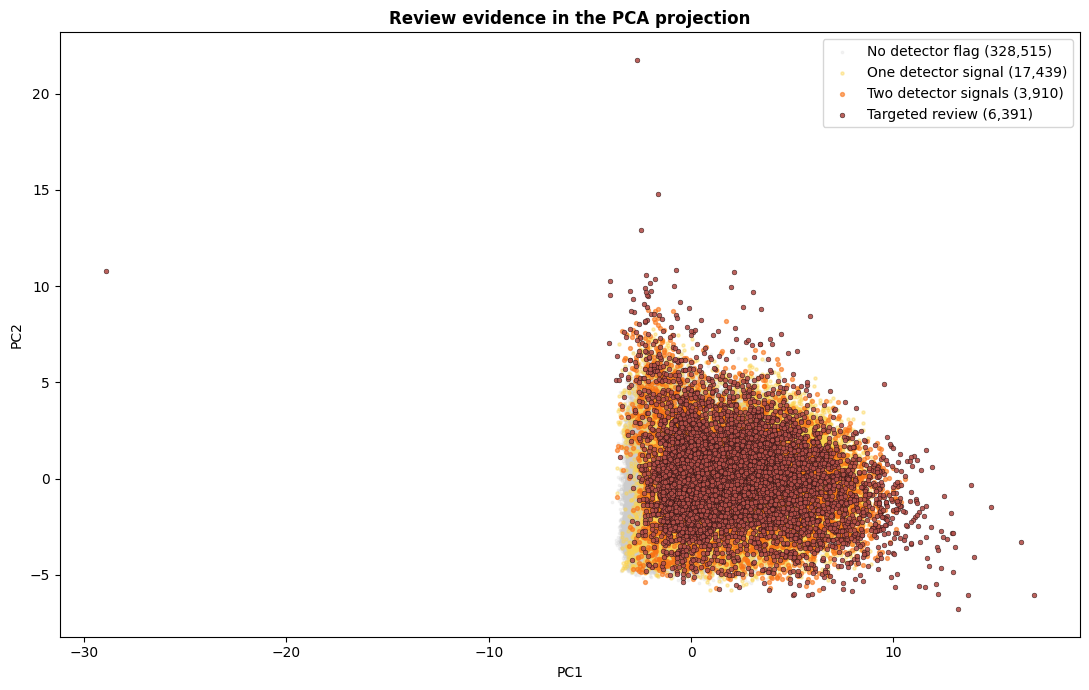

Saved pca_anomaly_sample.csv (35,831 rows for the dashboard)


In [9]:
# PCA scatter showing review-evidence bands
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2 = pca.fit_transform(X_scaled)
merged_a_indexed = merged_a.reset_index(drop=True)
merged_a_indexed['PC1'] = X_pca2[:, 0]
merged_a_indexed['PC2'] = X_pca2[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
no_flag = merged_a_indexed[merged_a_indexed['anomaly_category']=='NO_DETECTOR_FLAG']
one_signal = merged_a_indexed[merged_a_indexed['anomaly_category']=='ONE_DETECTOR_SIGNAL']
two_signals = merged_a_indexed[merged_a_indexed['anomaly_category']=='TWO_DETECTOR_SIGNAL']
review = merged_a_indexed[merged_a_indexed['anomaly_category']=='TARGETED_REVIEW']
ax.scatter(no_flag['PC1'], no_flag['PC2'], c='#CCCCCC', s=3, alpha=0.2, label=f'No detector flag ({len(no_flag):,})')
ax.scatter(one_signal['PC1'], one_signal['PC2'], c='#FCD34D', s=5, alpha=0.4, label=f'One detector signal ({len(one_signal):,})')
ax.scatter(two_signals['PC1'], two_signals['PC2'], c='#F97316', s=8, alpha=0.6, label=f'Two detector signals ({len(two_signals):,})')
ax.scatter(review['PC1'], review['PC2'], c='#B4504A', s=12, alpha=0.9, label=f'Targeted review ({len(review):,})', edgecolors='black', linewidths=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Review evidence in the PCA projection', fontweight='bold')
ax.legend()
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_pca_anomaly.png', dpi=150)
plt.show()

# Export every queued record plus a fixed sample of the remaining portfolio.
review_idx = np.where(merged_a_indexed['anomaly_category'] == 'TARGETED_REVIEW')[0]
rng_exp = np.random.default_rng(RANDOM_SEED)
base_idx = rng_exp.choice(len(merged_a_indexed), size=min(30000, len(merged_a_indexed)), replace=False)
keep_idx = np.unique(np.concatenate([base_idx, review_idx]))
merged_a_indexed.iloc[keep_idx][['PC1', 'PC2', 'anomaly_category', 'CLUSTER_KMEANS']].to_csv(
    OUT_DIR / 'pca_anomaly_sample.csv', index=False)
print(f'Saved pca_anomaly_sample.csv ({len(keep_idx):,} rows for the dashboard)')

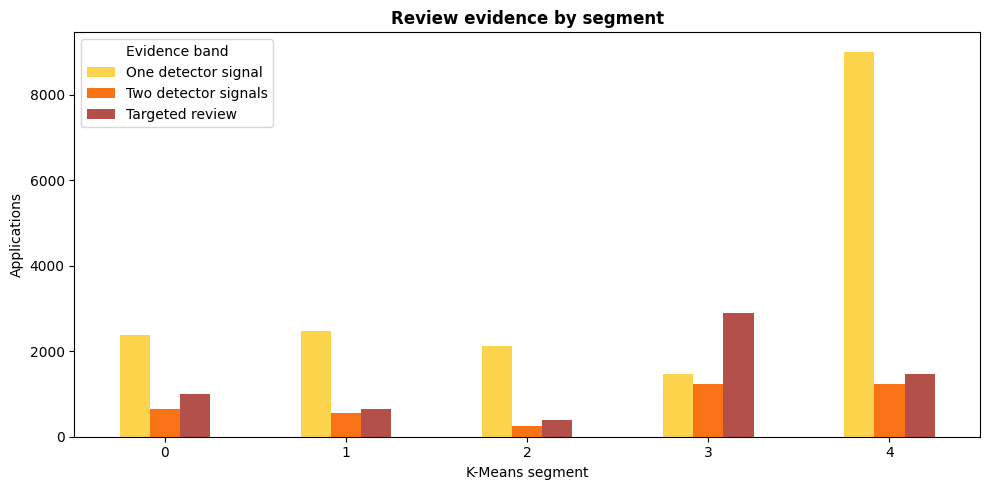

In [10]:
# Review evidence by K-Means segment
cluster_anomalies = merged_a.groupby('CLUSTER_KMEANS')['anomaly_category'].value_counts().unstack(fill_value=0)
if 'NO_DETECTOR_FLAG' in cluster_anomalies.columns:
    cluster_anomalies = cluster_anomalies.drop(columns=['NO_DETECTOR_FLAG'])
cluster_anomalies_sorted = cluster_anomalies.reindex(
    columns=['ONE_DETECTOR_SIGNAL', 'TWO_DETECTOR_SIGNAL', 'TARGETED_REVIEW'],
    fill_value=0,
)
cluster_anomalies_sorted = cluster_anomalies_sorted.rename(columns={
    'ONE_DETECTOR_SIGNAL': 'One detector signal',
    'TWO_DETECTOR_SIGNAL': 'Two detector signals',
    'TARGETED_REVIEW': 'Targeted review',
})
fig, ax = plt.subplots(figsize=(10, 5))
cluster_anomalies_sorted.plot(kind='bar', stacked=False, ax=ax,
                              color=['#FCD34D','#F97316','#B4504A'])
ax.set_xlabel('K-Means segment'); ax.set_ylabel('Applications')
ax.set_title('Review evidence by segment', fontweight='bold')
ax.legend(title='Evidence band')
plt.xticks(rotation=0)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_anomaly_per_cluster.png', dpi=150)
plt.show()

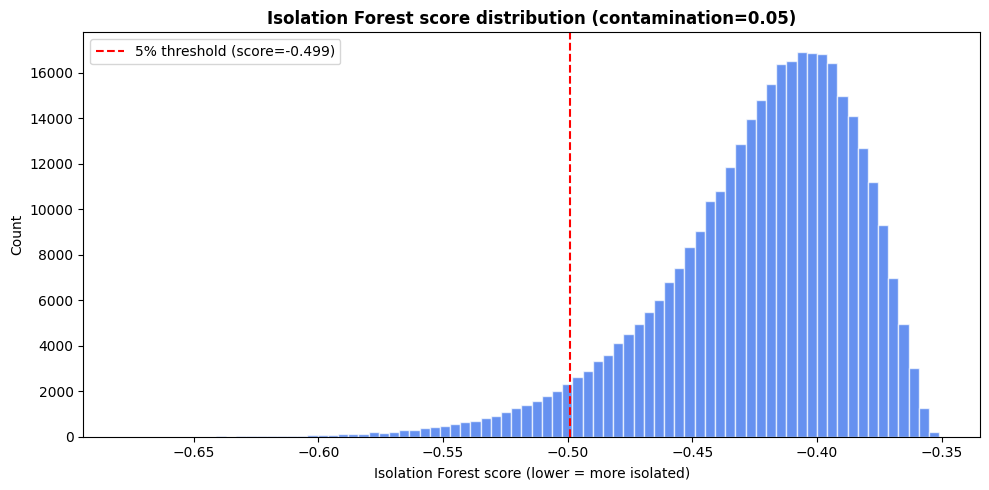

In [11]:
# Isolation Forest score distribution + threshold lines
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(iso_df['isolation_score'], bins=80, color='#2563EB', alpha=0.7, edgecolor='white')
thr05 = iso_df['isolation_score'].quantile(DEFAULT_CONTAM)
ax.axvline(thr05, color='red', ls='--', label=f'5% threshold (score={thr05:.3f})')
ax.set_xlabel('Isolation Forest score (lower = more isolated)')
ax.set_ylabel('Count')
ax.set_title(f'Isolation Forest score distribution (contamination={DEFAULT_CONTAM})', fontweight='bold')
ax.legend()
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_isolation_score_dist.png', dpi=150)
plt.show()

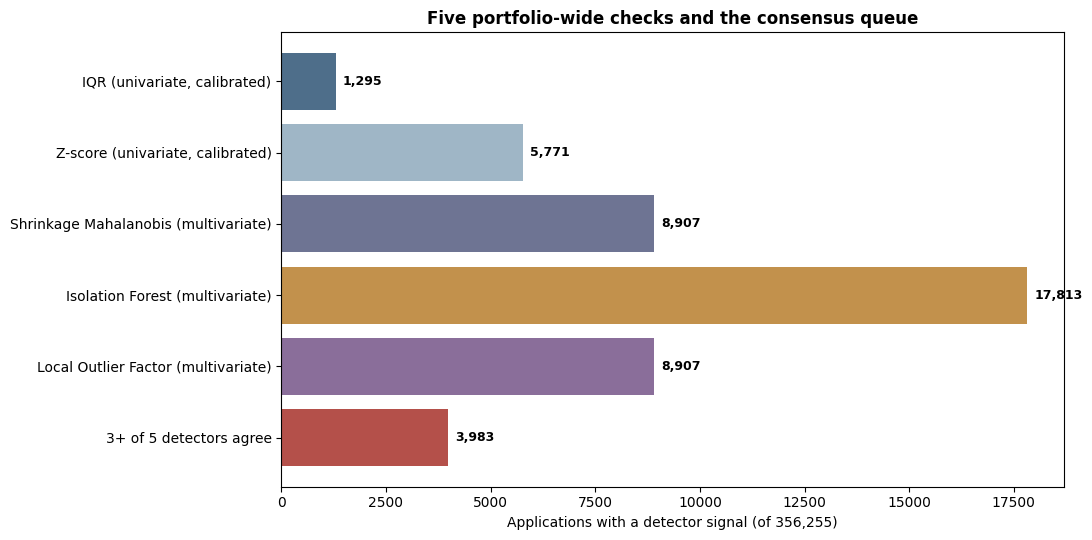

DBSCAN is not in this comparison: 356,255 sampled rows received that separate corroboration check.


In [12]:
# Per-method comparison: how many rows each portfolio-wide check surfaces,
# followed by the number admitted through 3-of-5 consensus.
method_counts = [
    ('IQR (univariate, calibrated)', int(merged_a['is_iqr_outlier'].sum()), '#4E6E8A'),
    ('Z-score (univariate, calibrated)', int(merged_a['is_zscore_outlier'].sum()), '#9FB6C6'),
    ('Shrinkage Mahalanobis (multivariate)', int(merged_a['is_mahalanobis_outlier'].sum()), '#6E7493'),
    ('Isolation Forest (multivariate)', int(merged_a['is_isolation_outlier'].sum()), '#C2914C'),
    ('Local Outlier Factor (multivariate)', int(merged_a['is_lof_outlier'].sum()), '#8A6E9A'),
    ('3+ of 5 detectors agree', int((merged_a['detection_count'] >= 3).sum()), '#B4504A'),
]
fig, ax = plt.subplots(figsize=(11, 5.5))
names_m = [m[0] for m in method_counts]
vals_m = [m[1] for m in method_counts]
cols_m = [m[2] for m in method_counts]
bars = ax.barh(names_m[::-1], vals_m[::-1], color=cols_m[::-1])
for bar, v in zip(bars, vals_m[::-1]):
    ax.text(v + max(vals_m)*0.01, bar.get_y() + bar.get_height()/2, f'{v:,}',
            va='center', fontsize=9, fontweight='bold')
ax.set_xlabel(f'Applications with a detector signal (of {len(merged_a):,})')
ax.set_title('Five portfolio-wide checks and the consensus queue', fontweight='bold')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_method_overlap.png', dpi=150)
plt.show()
print(
    f"DBSCAN is not in this comparison: {int(merged_a.dbscan_sample_covered.sum()):,} sampled rows "
    f"received that separate corroboration check."
)

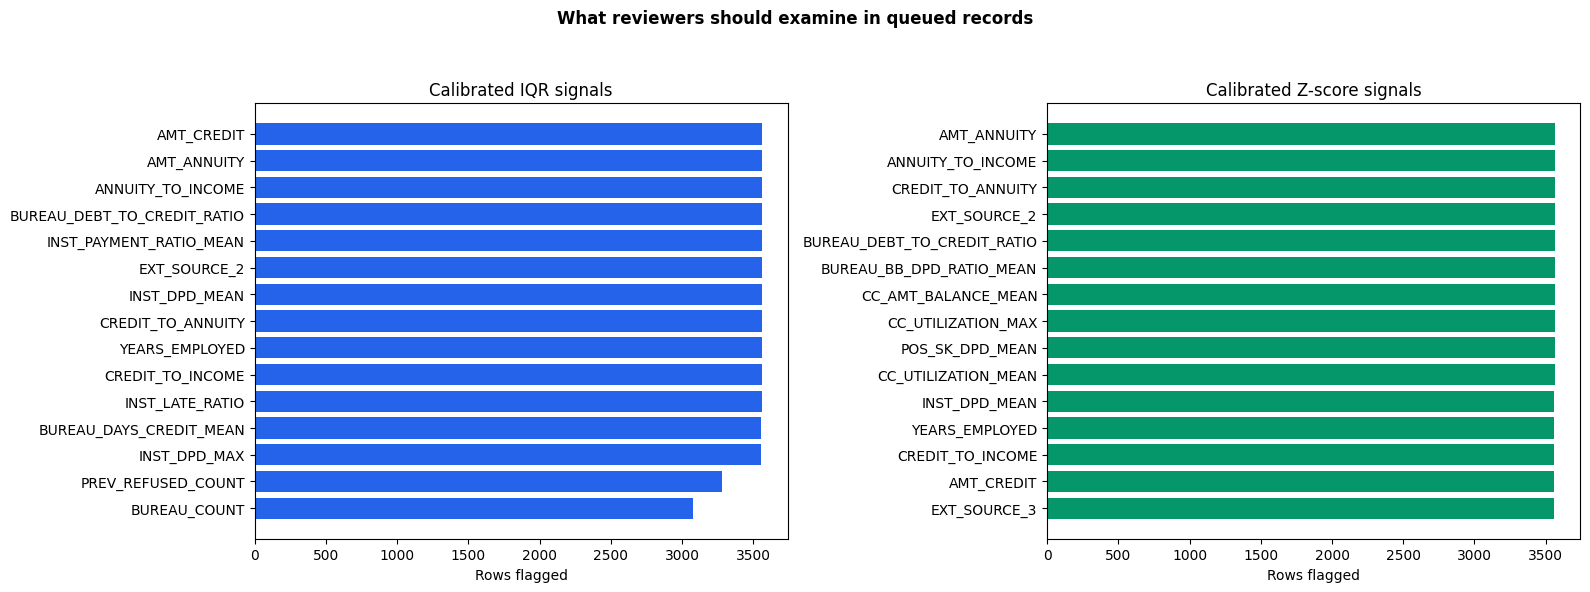

In [13]:
# Business-facing view of which source fields reviewers should verify
top_iqr_feats = iqr_flags.sum().sort_values(ascending=False).head(15)
top_z_feats = z_flags.sum().sort_values(ascending=False).head(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top_iqr_feats.index[::-1], top_iqr_feats.values[::-1], color='#2563EB')
fig.suptitle('What reviewers should examine in queued records', fontweight='bold')
axes[0].set_title('Calibrated IQR signals')
axes[0].set_xlabel('Rows flagged')
axes[1].barh(top_z_feats.index[::-1], top_z_feats.values[::-1], color='#059669')
axes[1].set_title('Calibrated Z-score signals')
axes[1].set_xlabel('Rows flagged')
plt.tight_layout(rect=[0, 0, 1, 0.94])
savefig_atomic(OUT_DIR / 'plot_anomaly_heatmap.png', dpi=150)
plt.show()

---
Phase 4 done. The artefacts are in `results/phase4_anomaly/`.

---
## 9. Business drivers and detector agreement

Counts alone do not explain the review workload. The first view groups the
business reasons for review; the second shows whether checks surface the same
records. Agreement supports review priority, but it does not predict early
payment difficulty. DBSCAN comparisons use only its Phase 2 sample.


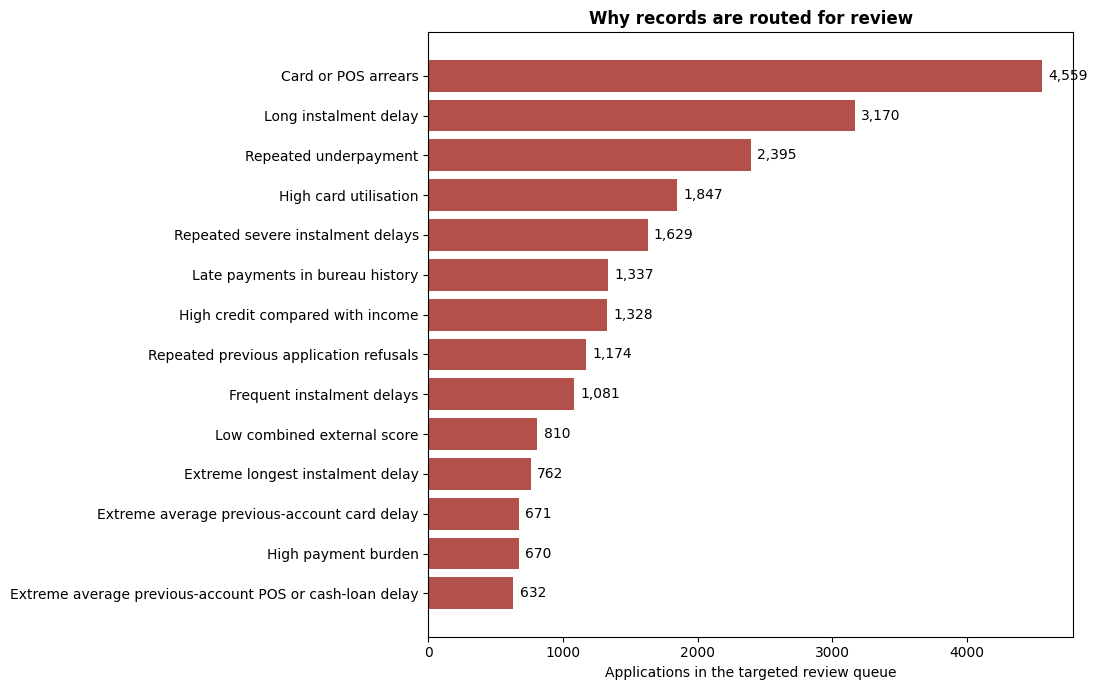

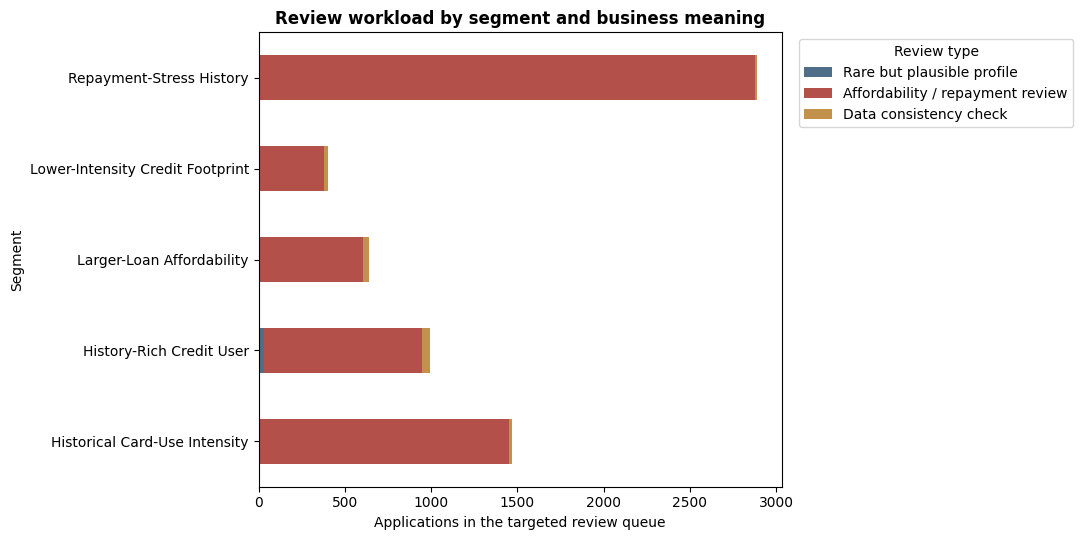

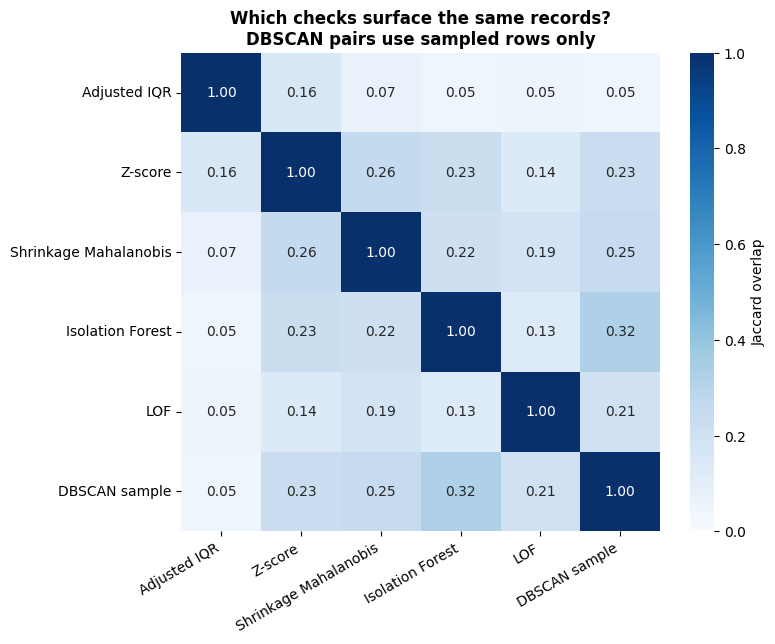

In [14]:
import seaborn as sns

top_drivers = driver_summary.head(14).sort_values('records')
fig, ax = plt.subplots(figsize=(11, 7))
colors = top_drivers['Review Type'].map({
    'Data consistency check': '#C2914C',
    'Affordability / repayment review': '#B4504A',
    'Rare but plausible profile': '#4E6E8A',
}).fillna('#6B7280')
bars = ax.barh(top_drivers['Driver'], top_drivers['records'], color=colors)
for bar, value in zip(bars, top_drivers['records']):
    ax.text(value + max(top_drivers['records']) * .01,
            bar.get_y() + bar.get_height()/2, f'{value:,}', va='center')
ax.set_xlabel('Applications in the targeted review queue')
ax.set_title('Why records are routed for review', fontweight='bold')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_anomaly_business_drivers.png', dpi=170, bbox_inches='tight')
plt.show()

review_by_segment = pd.crosstab(investigations['Segment'], investigations['Review Type'])
review_by_segment.to_csv(OUT_DIR / 'anomaly_review_by_segment.csv')
fig, ax = plt.subplots(figsize=(11, 5.5))
order = ['Rare but plausible profile', 'Affordability / repayment review', 'Data consistency check']
use = [c for c in order if c in review_by_segment.columns]
review_by_segment[use].plot(kind='barh', stacked=True, ax=ax,
    color=['#4E6E8A', '#B4504A', '#C2914C'][:len(use)])
ax.set_xlabel('Applications in the targeted review queue'); ax.set_ylabel('Segment')
ax.set_title('Review workload by segment and business meaning', fontweight='bold')
ax.legend(title='Review type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_anomaly_review_by_segment.png', dpi=170, bbox_inches='tight')
plt.show()

detector_cols = [
    ('Adjusted IQR', 'is_iqr_outlier', False),
    ('Z-score', 'is_zscore_outlier', False),
    ('Shrinkage Mahalanobis', 'is_mahalanobis_outlier', False),
    ('Isolation Forest', 'is_isolation_outlier', False),
    ('LOF', 'is_lof_outlier', False),
    ('DBSCAN sample', 'dbscan_sample_noise', True),
]
detector_names = [item[0] for item in detector_cols]
overlap = pd.DataFrame(index=detector_names, columns=detector_names, dtype=float)
overlap_denominators = []
portfolio_mask = pd.Series(True, index=merged_a.index)
for name_a, col_a, sampled_a in detector_cols:
    for name_b, col_b, sampled_b in detector_cols:
        comparison_mask = (
            merged_a['dbscan_sample_covered'] if sampled_a or sampled_b else portfolio_mask
        )
        a = merged_a.loc[comparison_mask, col_a].fillna(False).astype(bool)
        b = merged_a.loc[comparison_mask, col_b].fillna(False).astype(bool)
        intersection = int((a & b).sum())
        union = int((a | b).sum())
        overlap.loc[name_a, name_b] = intersection / union if union else 0.0
        overlap_denominators.append({
            'check_a': name_a, 'check_b': name_b,
            'eligible_rows': int(comparison_mask.sum()),
            'intersection_rows': intersection, 'jaccard_union_rows': union,
            'jaccard_overlap': overlap.loc[name_a, name_b],
        })
overlap.to_csv(OUT_DIR / 'detector_jaccard_overlap.csv')
pd.DataFrame(overlap_denominators).to_csv(
    OUT_DIR / 'detector_jaccard_overlap_denominators.csv', index=False)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(overlap.astype(float), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Jaccard overlap'}, ax=ax)
ax.set_title('Which checks surface the same records?\nDBSCAN pairs use sampled rows only',
             fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_detector_agreement_heatmap.png', dpi=170, bbox_inches='tight')
plt.show()


---
## 10. Threshold sensitivity

The assignment requires IQR, Z-score, and Isolation Forest. Conventional
textbook thresholds are shown beside the skew-adjusted/calibrated operating
choices so the queue is not presented as threshold-free truth. A detector's
selected review volume is an analytical choice, not evidence that a customer
will experience early payment difficulty.


In [15]:
conventional_iqr = pd.DataFrame(False, index=feat_sample.index, columns=cont_cols)
conventional_z = pd.DataFrame(False, index=feat_sample.index, columns=cont_cols)
for col in cont_cols:
    values = feat_sample[col]
    q1, q3 = values.quantile([.25, .75]); iqr = q3 - q1
    if iqr > 0:
        conventional_iqr[col] = (values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)
    z = np.abs(stats.zscore(values, nan_policy='omit'))
    conventional_z[col] = z > 3
threshold_sensitivity = pd.DataFrame([
    {'detector': 'IQR conventional 1.5x; 3+ columns',
     'records': int((conventional_iqr.sum(axis=1) >= MULTI_COL_RULE).sum())},
    {'detector': 'Adjusted IQR calibrated; 3+ columns',
     'records': int(stats_df['is_iqr_outlier'].sum())},
    {'detector': 'Z-score conventional |z|>3; 3+ columns',
     'records': int((conventional_z.sum(axis=1) >= MULTI_COL_RULE).sum())},
    {'detector': 'Z-score empirical 99th percentile; 3+ columns',
     'records': int(stats_df['is_zscore_outlier'].sum())},
] + [
    {'detector': f'Isolation Forest contamination {c:.0%}',
     'records': int(iso_df[f"is_isolation_outlier_{c}"].sum())}
    for c in CONTAMINATIONS
])
threshold_sensitivity['share'] = threshold_sensitivity['records'] / len(feat_sample)
threshold_sensitivity.to_csv(OUT_DIR / 'anomaly_threshold_sensitivity.csv', index=False)
print(threshold_sensitivity.to_string(index=False))


                                     detector  records    share
            IQR conventional 1.5x; 3+ columns    68297 0.191708
          Adjusted IQR calibrated; 3+ columns     1295 0.003635
       Z-score conventional |z|>3; 3+ columns     8124 0.022804
Z-score empirical 99th percentile; 3+ columns     5771 0.016199
            Isolation Forest contamination 1%     3563 0.010001
            Isolation Forest contamination 5%    17813 0.050001
           Isolation Forest contamination 10%    35626 0.100001


---
## 11. Outlier typology and its independence from Phase 2

### Why this section exists

Two questions have to be answered before the queue can be reported honestly.

**First, is the typology real or just a renamed queue route?** Point, collective, and contextual are only useful if each label is earned by its own evidence. Point is decided against the portfolio (at least 10 standard deviations on one prepared axis). Collective is decided against the sampled density view. Contextual is decided against the applicant's own segment: the largest robust deviation from that segment's median, using a median-absolute-deviation scale so a long-tailed field such as card balance cannot inflate the distance. The cell below prints how many contextual records clear three robust deviations from their own segment centre and how many are unusual only as a combination, so the class is auditable rather than residual.

**Second, does the queue simply rediscover the Phase 2 segments?** The Repayment-Stress History segment is defined by extreme instalment-delay features, and the detectors read the same feature matrix. A record five standard deviations above the mean on three delay columns is exactly what both procedures react to, so the concentration of the queue inside that segment could be an artefact of shared inputs rather than an independent result.

The leave-one-family-out test below settles it. The five detectors are re-run on the same applications with the entire delinquency family removed (`INST_DPD_MEAN`, `INST_DPD_MAX`, `INST_LATE_RATIO`, `INST_SEVERE_LATE_RATIO`, `POS_SK_DPD_MEAN`, `CC_SK_DPD_MEAN`). Those six columns are the ones that give the segment its identity. If the segment still absorbs a disproportionate share of the queue after they are gone, the concentration reflects something about those applications beyond the axis that named them. If the concentration collapses, the finding is circular and must be reported as such.


In [16]:
# ---------------------------------------------------------------- typology
# The typology comes from the exported investigation, which records the
# evidence that earned each label rather than the route that admitted it.
typology_counts = investigations['Outlier Type'].value_counts()
peer_basis = investigations['Typology Basis'].str.startswith('Segment reference')
combo_basis = investigations['Typology Basis'].str.startswith('Combination reference')
contextual = investigations['Outlier Type'].str.startswith('Contextual')

print('Outlier typology (evidence-earned):')
for name, count in typology_counts.items():
    print(f'  {name:52s} {count:>6,}')

print(f'\nContextual records: {int(contextual.sum()):,}')
print(f'  peer-extreme (>=3 robust deviations from own segment median): {int((contextual & peer_basis).sum()):,}')
print(f'  combination-only (no single field beyond that distance)     : {int((contextual & combo_basis).sum()):,}')
peer_scores = investigations.loc[contextual & peer_basis, 'Peer Deviation']
if len(peer_scores):
    print(f'  peer deviation among peer-extreme records: median {peer_scores.median():.1f}, '
          f'p90 {peer_scores.quantile(.90):.1f}, max {peer_scores.max():.1f}')

typology_table = (
    # The label is derived from the basis string itself rather than hardcoded,
    # so a change to how a label is earned cannot silently leave this summary
    # describing the previous method.
    investigations.assign(
        basis=investigations['Typology Basis'].str.split(':', n=1).str[0].str.strip())
    .groupby(['Outlier Type', 'basis'], as_index=False)
    .agg(records=('SK_ID_CURR', 'nunique'),
         median_peer_deviation=('Peer Deviation', 'median'))
    .sort_values('records', ascending=False)
)
typology_table.to_csv(OUT_DIR / 'anomaly_typology_basis.csv', index=False)
print('\nSaved anomaly_typology_basis.csv')
print(typology_table.to_string(index=False))


Outlier typology (evidence-earned):
  Point (globally extreme single value)                 4,334
  Contextual (unusual against its own segment)          1,982
  Collective (mutually linked separated group)             75

Contextual records: 1,982
  peer-extreme (>=3 robust deviations from own segment median): 1,489
  combination-only (no single field beyond that distance)     : 493
  peer deviation among peer-extreme records: median 5.9, p90 19.3, max 10322.6

Saved anomaly_typology_basis.csv
                                Outlier Type                 basis  records  median_peer_deviation
       Point (globally extreme single value)   Portfolio reference     4334                 3.8545
Contextual (unusual against its own segment)     Segment reference     1489                 5.8520
Contextual (unusual against its own segment) Combination reference      493                 2.1280
Collective (mutually linked separated group)       Group reference       75                 3.4570


### Reading the leave-one-family-out result

The comparison below reports, for each segment, the share of the queue it holds under the full feature set and under the reduced feature set. The right-hand column is the ratio. A ratio near 1 means the segment's queue share does not depend on the six delinquency columns. A ratio far below 1 means it does, and the original share was substantially a restatement of how the segment was formed.


Removing 6 delinquency columns: ['INST_DPD_MEAN', 'INST_DPD_MAX', 'INST_LATE_RATIO', 'INST_SEVERE_LATE_RATIO', 'POS_SK_DPD_MEAN', 'CC_SK_DPD_MEAN']

Reduced matrix: 35 features, 26 continuous


  Five reduced detectors completed in 71.0s


  Reduced queue: 3,416 records (full queue 6,391)



Queue share by segment, full versus delinquency-free feature set:
                         Segment  share_of_applications  share_of_queue_full  share_of_queue_reduced  retained_ratio
        Repayment-Stress History                   2.14                45.17                    6.09           0.135
   Historical Card-Use Intensity                  15.31                23.02                   38.55           1.675
        History-Rich Credit User                  14.49                15.55                   29.95           1.925
       Larger-Loan Affordability                  34.62                10.00                   16.48           1.648
Lower-Intensity Credit Footprint                  33.44                 6.26                    8.93           1.427

The two specialist segments hold 17.45% of applications.
  Queue share with the delinquency family : 68.19%
  Queue share without it                  : 44.64%
  Retained ratio                          : 0.655
A ratio close to 1 me

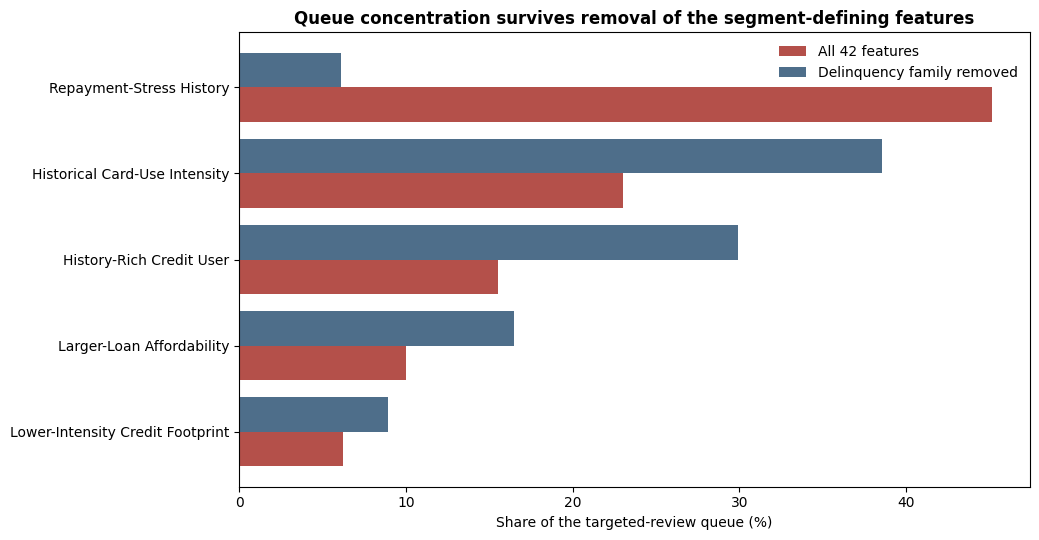

In [17]:
# ------------------------------------------- leave-one-family-out circularity test
# Re-run all five detectors without the six columns that give the
# Repayment-Stress History segment its identity. Everything else, including the
# calibration targets, consensus rule, and single-axis cut-off, is unchanged.
DELINQUENCY_FAMILY = [
    'INST_DPD_MEAN', 'INST_DPD_MAX', 'INST_LATE_RATIO',
    'INST_SEVERE_LATE_RATIO', 'POS_SK_DPD_MEAN', 'CC_SK_DPD_MEAN',
]
present_family = [c for c in DELINQUENCY_FAMILY if c in feat_sample.columns]
print(f'Removing {len(present_family)} delinquency columns: {present_family}')

feat_reduced = feat_sample.drop(columns=present_family)
cont_reduced = [c for c in cont_cols if c not in present_family]
print(f'Reduced matrix: {feat_reduced.shape[1]} features, {len(cont_reduced)} continuous')

t0 = time.time()
iqr_r, _, _ = flag_iqr_adjusted(feat_reduced, cont_reduced)
z_r, _ = flag_zscore(feat_reduced, cont_reduced)
X_red = StandardScaler().fit_transform(feat_reduced)
iso_r = IsolationForest(n_estimators=100, contamination=DEFAULT_CONTAM,
                        random_state=RANDOM_SEED, n_jobs=-1).fit_predict(X_red) == -1
Xc_red = feat_reduced[cont_reduced].values.astype(np.float64)
mahal_r_model = LedoitWolf(store_precision=True, assume_centered=False, block_size=1000).fit(Xc_red)
mahal_r_d2 = mahal_r_model.mahalanobis(Xc_red)
mahal_r = mahal_r_d2 > np.quantile(mahal_r_d2, 0.975)
lof_r_a = LocalOutlierFactor(n_neighbors=LOF_NEIGHBORS, novelty=True, metric='euclidean', n_jobs=-1)
lof_r_b = LocalOutlierFactor(n_neighbors=LOF_NEIGHBORS, novelty=True, metric='euclidean', n_jobs=-1)
lof_r_a.fit(Xc_red[lof_ref_a]); lof_r_b.fit(Xc_red[lof_ref_b])
lof_r_score = np.empty(len(Xc_red))
lof_r_score[~lof_in_ref_a] = -lof_r_a.score_samples(Xc_red[~lof_in_ref_a])
lof_r_score[lof_in_ref_a] = -lof_r_b.score_samples(Xc_red[lof_in_ref_a])
lof_r = lof_r_score > np.quantile(lof_r_score, 0.975)
print(f'  Five reduced detectors completed in {time.time()-t0:.1f}s')

reduced_count = (
    (iqr_r.sum(axis=1) >= MULTI_COL_RULE).astype(int).to_numpy()
    + (z_r.sum(axis=1) >= MULTI_COL_RULE).astype(int).to_numpy()
    + mahal_r.astype(int) + iso_r.astype(int) + lof_r.astype(int))
reduced_max_z = feat_reduced.abs().max(axis=1).to_numpy()
reduced_queue = (reduced_count >= 3) | (reduced_max_z >= EXTREME_SINGLE_AXIS_Z)
print(f'  Reduced queue: {int(reduced_queue.sum()):,} records '
      f'(full queue {int(merged_a["queue_route"].ne("Not queued").sum()):,})')

segment_name = merged_a['CLUSTER_KMEANS'].map(
    dict(zip(cluster_names_df['cluster_id'], cluster_names_df['segment_name'])))
full_queue = merged_a['queue_route'].ne('Not queued').to_numpy()
circularity = pd.DataFrame({
    'Segment': segment_name,
    'full': full_queue,
    'reduced': reduced_queue,
}).groupby('Segment').agg(
    applications=('full', 'size'),
    queue_full=('full', 'sum'),
    queue_reduced=('reduced', 'sum'),
).reset_index()
circularity['share_of_queue_full'] = circularity['queue_full'] / circularity['queue_full'].sum()
circularity['share_of_queue_reduced'] = circularity['queue_reduced'] / circularity['queue_reduced'].sum()
circularity['retained_ratio'] = (
    circularity['share_of_queue_reduced'] / circularity['share_of_queue_full'])
circularity['share_of_applications'] = circularity['applications'] / circularity['applications'].sum()
circularity = circularity.sort_values('share_of_queue_full', ascending=False)
circularity.to_csv(OUT_DIR / 'anomaly_circularity_check.csv', index=False)

print('\nQueue share by segment, full versus delinquency-free feature set:')
print(circularity[['Segment', 'share_of_applications', 'share_of_queue_full',
                   'share_of_queue_reduced', 'retained_ratio']]
      .assign(**{c: lambda d, c=c: (d[c] * 100).round(2)
                 for c in ['share_of_applications', 'share_of_queue_full', 'share_of_queue_reduced']})
      .round(3).to_string(index=False))

stress = circularity.loc[circularity['Segment'].eq('Repayment-Stress History')].iloc[0]
card = circularity.loc[circularity['Segment'].eq('Historical Card-Use Intensity')].iloc[0]
pair_full = stress['share_of_queue_full'] + card['share_of_queue_full']
pair_reduced = stress['share_of_queue_reduced'] + card['share_of_queue_reduced']
pair_apps = stress['share_of_applications'] + card['share_of_applications']
print(f'\nThe two specialist segments hold {pair_apps:.2%} of applications.')
print(f'  Queue share with the delinquency family : {pair_full:.2%}')
print(f'  Queue share without it                  : {pair_reduced:.2%}')
print(f'  Retained ratio                          : {pair_reduced / pair_full:.3f}')
print('A ratio close to 1 means the concentration does not depend on the columns that '
      'named the segment; a low ratio means the original figure restated Phase 2.')

fig, ax = plt.subplots(figsize=(10.5, 5.5))
order = circularity.sort_values('share_of_queue_full')
y = np.arange(len(order))
ax.barh(y - .2, order['share_of_queue_full'] * 100, height=.4,
        color='#B4504A', label='All 42 features')
ax.barh(y + .2, order['share_of_queue_reduced'] * 100, height=.4,
        color='#4E6E8A', label='Delinquency family removed')
ax.set_yticks(y); ax.set_yticklabels(order['Segment'])
ax.set_xlabel('Share of the targeted-review queue (%)')
ax.set_title('Queue concentration survives removal of the segment-defining features',
             fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_anomaly_circularity.png', dpi=170, bbox_inches='tight')
plt.show()


---
## 12. Where the money is, where the attention goes, and where the evidence is

### The question the three phases can answer together that none can answer alone

Phase 2 knows which segment carries the committed amount. Phase 4 knows which segment absorbs the review queue. Phase 1 knows how much history each segment actually has on file. Individually each of those is close to a restatement of how the segment was built. Put side by side against the same denominator, they answer a question the bank cannot read off any single table: **is scrutiny pointed at the money, and does the evidence exist where the scrutiny is pointed?**

That framing matters in this domain specifically. Home Credit lends to applicants with thin conventional files, so the binding constraint on an underwriting decision is not usually the size of the loan, it is whether anything can be verified about the applicant. A control system that spends its capacity where records are plentiful is spending it where verification was already easy.

Three ratios are computed per segment, all against the same 356,255 applications:

* **amount share**, the segment's share of recorded loan value,
* **queue share**, its share of the targeted-review queue built in this phase,
* **evidence depth**, the median number of previous applications and instalment records on file.

The **amount-to-attention ratio** is amount share divided by queue share. Above 1 means the segment holds more of the committed value than it receives of the automated review attention. This number cannot be produced by either phase alone, and neither phase can manufacture it, because the queue is built from a different matrix, different methods, and thresholds that never reference loan size.


Amount, attention, and evidence depth on the same 356,255 applications:
                         Segment  application_share  amount_share  queue_share  amount_to_attention  median_prev_applications  median_instalment_records  queue_rate_within_segment
       Larger-Loan Affordability              34.62         53.21        10.00                 5.32                       2.0                       16.0                       0.52
   Historical Card-Use Intensity              15.31         16.03        23.02                 0.70                       6.0                       97.0                       2.70
Lower-Intensity Credit Footprint              33.44         15.74         6.26                 2.51                       3.0                       15.0                       0.34
        History-Rich Credit User              14.49         12.96        15.55                 0.83                      10.0                       49.0                       1.93
        Repayment-Stress His

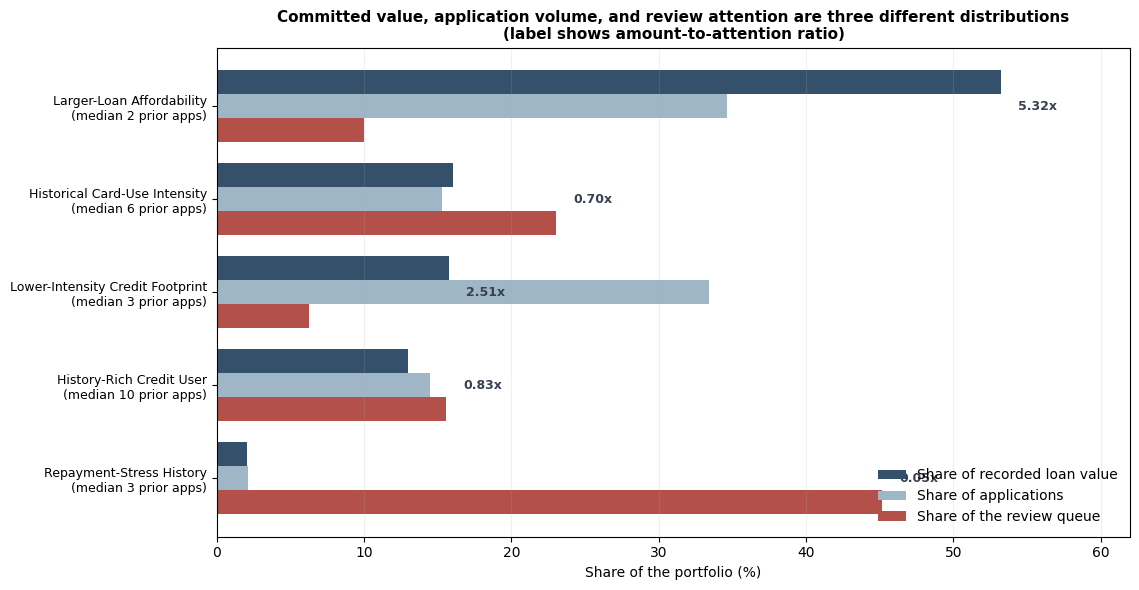

In [18]:
# ------------- amount, attention, and evidence on one denominator
amount_col = 'SOURCE_AMT_CREDIT' if 'SOURCE_AMT_CREDIT' in business_values.columns else 'AMT_CREDIT'
annuity_col = 'SOURCE_AMT_ANNUITY' if 'SOURCE_AMT_ANNUITY' in business_values.columns else 'AMT_ANNUITY'
name_by_cid = dict(zip(cluster_names_df['cluster_id'], cluster_names_df['segment_name']))

alignment_base = business_values.merge(
    labels[['ROW_ID', 'CLUSTER_KMEANS']], on='ROW_ID', how='inner', validate='one_to_one')
alignment_base['Segment'] = alignment_base['CLUSTER_KMEANS'].map(name_by_cid)
queue_by_segment = investigations['Segment'].value_counts()

alignment = alignment_base.groupby('Segment').agg(
    applications=('ROW_ID', 'size'),
    amount=(amount_col, 'sum'),
    annuity=(annuity_col, 'sum'),
    median_prev_applications=('PREV_COUNT', 'median'),
    median_instalment_records=('INST_COUNT', 'median'),
    median_bureau_records=('BUREAU_COUNT', 'median'),
    share_without_bureau=('FLAG_NO_BUREAU', 'mean'),
).reset_index()
alignment['application_share'] = alignment['applications'] / alignment['applications'].sum()
alignment['amount_share'] = alignment['amount'] / alignment['amount'].sum()
alignment['annuity_share'] = alignment['annuity'] / alignment['annuity'].sum()
alignment['queue_records'] = alignment['Segment'].map(queue_by_segment).fillna(0).astype(int)
alignment['queue_share'] = alignment['queue_records'] / alignment['queue_records'].sum()
alignment['queue_rate_within_segment'] = alignment['queue_records'] / alignment['applications']
alignment['amount_to_attention'] = alignment['amount_share'] / alignment['queue_share']

# The two ratios a credit committee can actually act on. A share is hard to
# staff against; "how much committed money does one review cover" is not.
alignment['value_covered_per_review'] = alignment['amount'] / alignment['queue_records']
alignment['applications_per_review'] = alignment['applications'] / alignment['queue_records']
_floor = alignment['value_covered_per_review'].min()
alignment['value_per_review_vs_lowest'] = alignment['value_covered_per_review'] / _floor
alignment = alignment.sort_values('amount_share', ascending=False)
alignment.to_csv(OUT_DIR / 'segment_amount_attention_alignment.csv', index=False)

show = alignment[['Segment', 'application_share', 'amount_share', 'queue_share',
                  'amount_to_attention', 'median_prev_applications',
                  'median_instalment_records', 'queue_rate_within_segment']].copy()
for col in ['application_share', 'amount_share', 'queue_share', 'queue_rate_within_segment']:
    show[col] = (show[col] * 100).round(2)
print('Amount, attention, and evidence depth on the same 356,255 applications:')
print(show.round(2).to_string(index=False))

lead = alignment.iloc[0]
tail = alignment.sort_values('amount_to_attention').iloc[0]
print(f"\n{lead['Segment']}: {lead['amount_share']:.2%} of recorded loan value, "
      f"{lead['queue_share']:.2%} of the review queue, "
      f"amount-to-attention {lead['amount_to_attention']:.2f}.")
print(f"  Evidence on file: median {lead['median_prev_applications']:.0f} previous applications and "
      f"{lead['median_instalment_records']:.0f} instalment records, "
      f"{lead['share_without_bureau']:.1%} with no bureau record at all.")
print(f"{tail['Segment']}: {tail['amount_share']:.2%} of value, {tail['queue_share']:.2%} of the queue, "
      f"amount-to-attention {tail['amount_to_attention']:.2f}.")
print(f"\nSpread between the highest and lowest amount-to-attention ratio: "
      f"{alignment['amount_to_attention'].max() / alignment['amount_to_attention'].min():.0f}x.")
print('The queue never reads loan size, so this spread is not built into either phase.')

# Restate the same fact in the unit a review manager staffs against.
print()
print('Committed value covered by one review, by segment:')
for _, row in alignment.sort_values('value_covered_per_review', ascending=False).iterrows():
    print(f"  {row['Segment']:34s} {row['value_covered_per_review']/1e6:8.1f}M units per review "
          f"({row['value_per_review_vs_lowest']:6.1f}x the lowest), "
          f"one review per {row['applications_per_review']:6.1f} applications")
_hi = alignment.loc[alignment['value_covered_per_review'].idxmax()]
_lo = alignment.loc[alignment['value_covered_per_review'].idxmin()]
print()
print(f"One review in {_hi['Segment']} carries "
      f"{_hi['value_covered_per_review'] / _lo['value_covered_per_review']:.0f} times the committed value "
      f"of one review in {_lo['Segment']}.")
print('That is the sentence a review manager can act on: it converts a share of a queue')
print('into the amount of money each hour of review effort is actually standing behind.')

# ------------------------------------------------------------------ the chart
fig, ax = plt.subplots(figsize=(11.5, 6))
order = alignment.sort_values('amount_share')
y = np.arange(len(order))
ax.barh(y + .26, order['amount_share'] * 100, height=.26, color='#34506B',
        label='Share of recorded loan value')
ax.barh(y, order['application_share'] * 100, height=.26, color='#9FB6C6',
        label='Share of applications')
ax.barh(y - .26, order['queue_share'] * 100, height=.26, color='#B4504A',
        label='Share of the review queue')
for idx, (_, row) in enumerate(order.iterrows()):
    ax.text(max(row['amount_share'], row['queue_share']) * 100 + 1.2, idx,
            f"{row['amount_to_attention']:.2f}x", va='center', fontsize=9,
            fontweight='bold', color='#374151')
ax.set_yticks(y)
ax.set_yticklabels([f"{s}\n(median {p:.0f} prior apps)"
                    for s, p in zip(order['Segment'], order['median_prev_applications'])],
                   fontsize=9)
ax.set_xlabel('Share of the portfolio (%)')
ax.set_xlim(0, 62)
ax.set_title('Committed value, application volume, and review attention are three different '
             'distributions\n(label shows amount-to-attention ratio)', fontweight='bold', fontsize=11)
ax.legend(frameon=False, loc='lower right')
ax.grid(alpha=.18, axis='x')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_amount_attention_alignment.png', dpi=170, bbox_inches='tight')
plt.show()


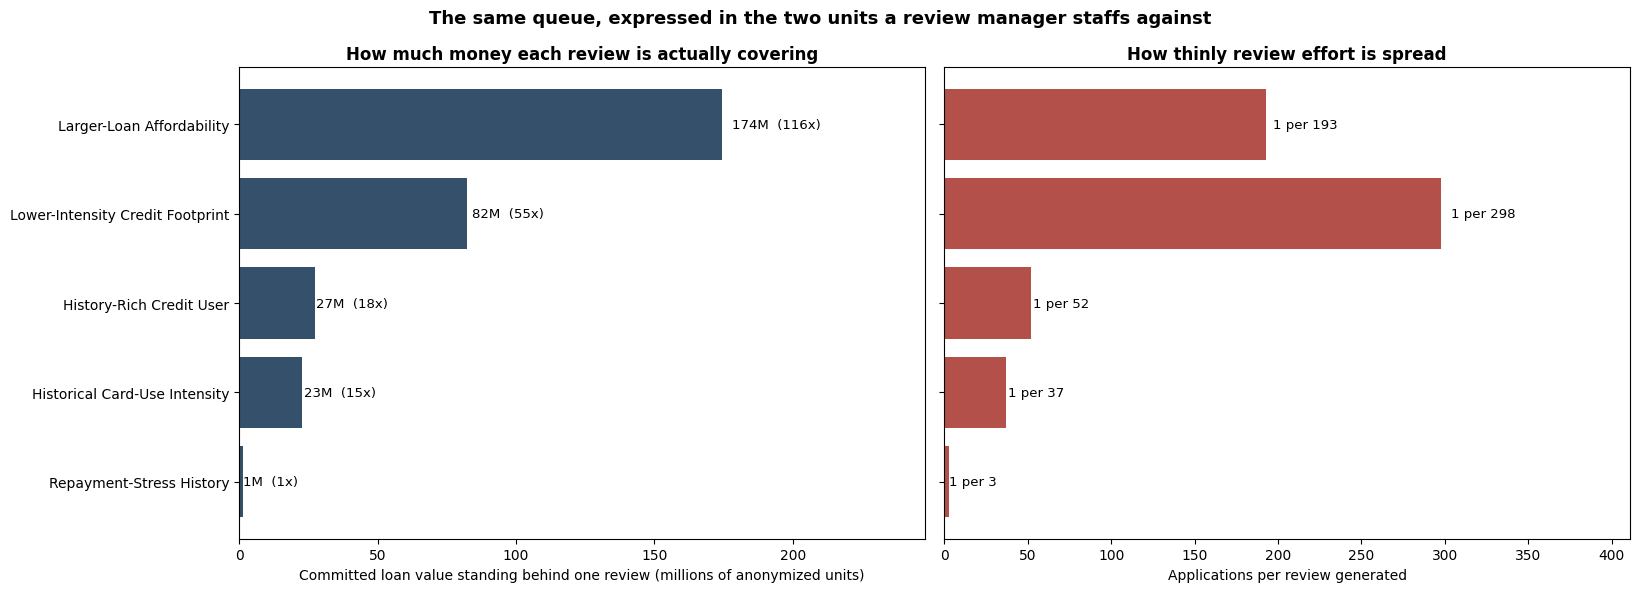

Read the two panels together. The segment whose reviews each stand behind the most
money is also the segment where review effort is spread thinnest across applications.
Neither panel says those applications are worse. Both say the control system is
currently allocating scrutiny by how much history exists rather than by how much
money is committed, which is a policy choice the bank has not explicitly made.


In [19]:
# ------------------------------- the same finding in the unit a manager staffs against
order = alignment.sort_values('value_covered_per_review')
fig, axes = plt.subplots(1, 2, figsize=(16.5, 6))

ax = axes[0]
bars = ax.barh(order['Segment'], order['value_covered_per_review'] / 1e6, color='#34506B')
for bar, (_, row) in zip(bars, order.iterrows()):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
            f"{row['value_covered_per_review']/1e6:,.0f}M  ({row['value_per_review_vs_lowest']:.0f}x)",
            va='center', fontsize=9.5)
ax.set_xlabel('Committed loan value standing behind one review (millions of anonymized units)')
ax.set_title('How much money each review is actually covering', fontweight='bold')
ax.set_xlim(0, order['value_covered_per_review'].max() / 1e6 * 1.42)

ax = axes[1]
bars = ax.barh(order['Segment'], order['applications_per_review'], color='#B4504A')
for bar, (_, row) in zip(bars, order.iterrows()):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
            f"1 per {row['applications_per_review']:,.0f}", va='center', fontsize=9.5)
ax.set_xlabel('Applications per review generated')
ax.set_title('How thinly review effort is spread', fontweight='bold')
ax.set_xlim(0, order['applications_per_review'].max() * 1.38)
ax.set_yticklabels([])

plt.suptitle('The same queue, expressed in the two units a review manager staffs against',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_review_coverage.png', dpi=170, bbox_inches='tight')
plt.show()

print('Read the two panels together. The segment whose reviews each stand behind the most')
print('money is also the segment where review effort is spread thinnest across applications.')
print('Neither panel says those applications are worse. Both say the control system is')
print('currently allocating scrutiny by how much history exists rather than by how much')
print('money is committed, which is a policy choice the bank has not explicitly made.')


### What this does and does not establish

The alignment is a statement about where a control system currently points, not about applicant quality. A low amount-to-attention ratio is not evidence that a segment is safe, and a high one is not evidence that a segment is dangerous. Two readings are ruled out explicitly:

* it does not say that the large-amount segment contains worse applicants, because no outcome is observed anywhere in this project, and
* it does not say the queue is misconfigured, because the detectors were never asked to weight by loan size and would be wrong to do so on their own.

What it does establish is that the three distributions are different, that the difference is large, and that the segment holding the most committed value is also the one with the least history available to verify it. That combination is a policy question about where verification effort is allocated, and it is the discovery that no single phase could produce.
